| Hyp. | Segment | erwartetes Profil |
|------|---------|-------------------|
| **H1** | Familien | viel Wohn-/Grundstücksfläche, mehr Schlaf-/Badezimmer, eher außerhalb |
| **H2** | urbane Singles/Paare | kleinere Fläche, wenige Zimmer, zentrumsnah |
| **H3** | Luxus-Käufer | hoher Preis, hoher `luxury_score`, viel Fläche |
| **H4** | Erstkäufer | niedriger Preis, kleine/mittlere Fläche, wenige Zimmer, moderate Zentrumsnähe (günstiges Einstiegssegment) |

Ziel: Prüfen, ob sich diese Segmente datengetrieben (Clustering) wiederfinden lassen, und die Cluster-Algorithmen vergleichen (K-Means, Hierarchical, DBSCAN, HDBSCAN, GMM) samt Bewertung (Elbow/SSE, Silhouette, Davies-Bouldin).

## 1 · Setup & Daten laden

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN, HDBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.neighbors import NearestNeighbors

RANDOM_STATE = 42
SIL_SAMPLE   = 3000   # Stichprobe für Silhouette (O(n^2) -> auf 21k zu teuer)
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110

In [2]:
df = pd.read_csv("cleaned_house_data.csv")
X = df.values
print("Shape:", df.shape)
print("Fehlende Werte gesamt:", int(df.isna().sum().sum()))
df.head()

Shape: (21420, 8)
Fehlende Werte gesamt: 0


,log_price,log_sqft_living,log_yard_space_approx,bedrooms,bathrooms,luxury_score,distance_to_center,years_since_renovation
0,-0.131996,-0.643408,0.160081,0.694872,-1.454958,0.020242,-0.009709,0.676342
1,0.333223,1.303083,-0.231365,0.694872,0.496383,-0.428990,2.219512,-1.336720
2,0.315941,0.043146,0.303233,0.694872,0.496383,0.020242,0.249930,-0.087233
3,-0.873625,-0.367450,-2.268759,-1.520031,0.496383,-0.709759,-1.114612,-1.232596
4,1.007432,0.733706,-0.994394,-0.412580,0.496383,0.581781,-0.805474,0.780466


In [3]:
# Kurzer Skalen-Check: sollte Mittel ~0 und Std ~1 sein (aus M3)
df.describe().T[["mean", "std", "min", "max"]].round(3)

,mean,std,min,max
log_price,0.0,1.0,-3.414,5.355
log_sqft_living,-0.0,1.0,-3.864,4.625
log_yard_space_approx,0.0,1.0,-8.203,5.246
bedrooms,0.0,1.0,-2.627,8.447
bathrooms,0.0,1.0,-2.105,7.651
luxury_score,0.0,1.0,-3.012,6.740
distance_to_center,0.0,1.0,-1.542,6.751
years_since_renovation,-0.0,1.0,-1.441,2.551


## Kurze EDA: Verteilungen & Korrelationen


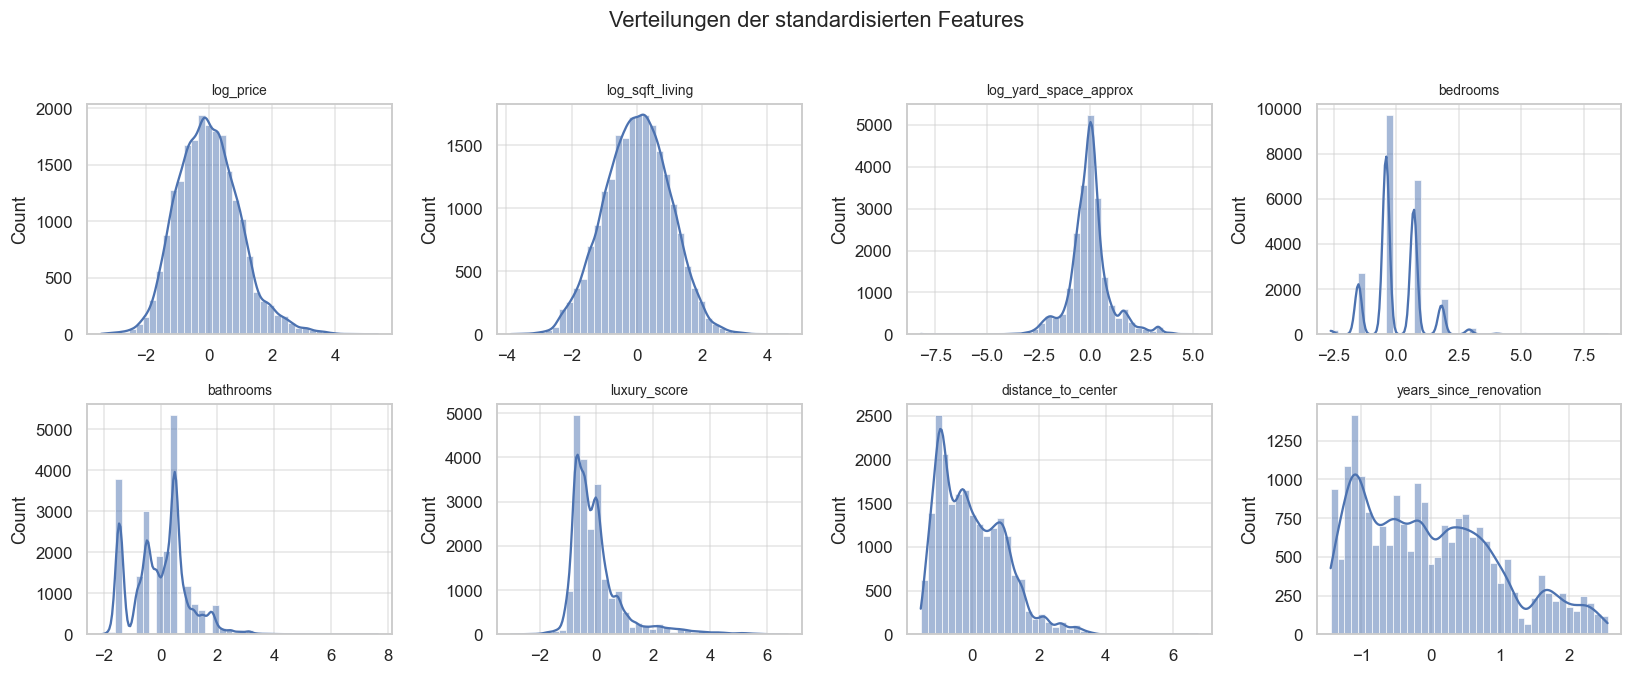

In [4]:
fig, axes = plt.subplots(2, 4, figsize=(15, 6))
for ax, col in zip(axes.ravel(), df.columns):
    sns.histplot(df[col], bins=40, kde=True, ax=ax, color="#4C72B0")
    ax.set_title(col, fontsize=9)
    ax.set_xlabel("")
fig.suptitle("Verteilungen der standardisierten Features", y=1.02)
plt.tight_layout(); plt.show()

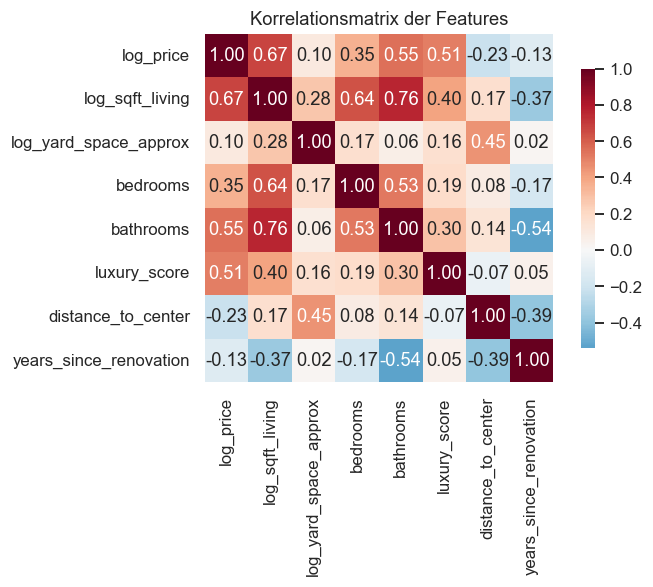

In [5]:
plt.figure(figsize=(7, 5.5))
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            square=True, cbar_kws={"shrink": .8})
plt.title("Korrelationsmatrix der Features")
plt.tight_layout(); plt.show()

**Lesart:** Stark korrelierte Blöcke (z. B. Preis ↔ Fläche ↔ `luxury_score`) deuten schon an, dass sich „groß & teuer" vs. „klein & zentral" als Achsen trennen lassen – genau die Richtung unserer Hypothesen.

## PCA (2D) – nur zur Visualisierung
Clustering läuft auf **allen 8 Features**. Für die Plots projizieren wir die Cluster auf die ersten beiden Hauptkomponenten, weil man 8 Dimensionen nicht direkt zeichnen kann. Die PCA wird *nicht* zum Clustern verwendet.

Erklärte Varianz: PC1=40.5%, PC2=20.1%, zusammen=60.7%


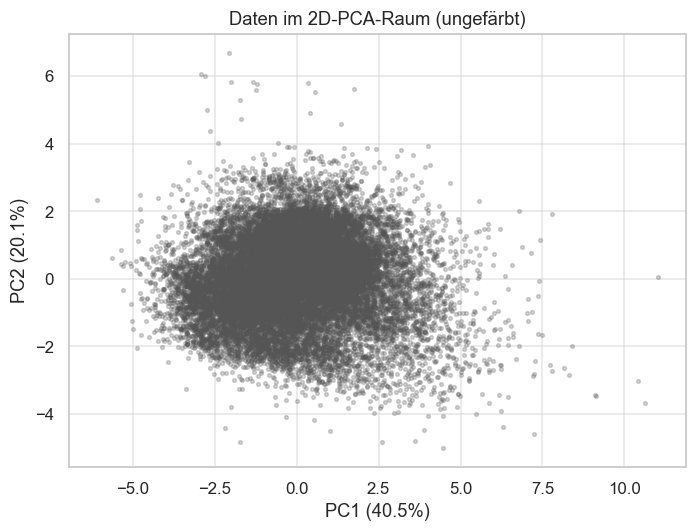

In [6]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X)
ev = pca.explained_variance_ratio_
print(f"Erklärte Varianz: PC1={ev[0]:.1%}, PC2={ev[1]:.1%}, zusammen={ev.sum():.1%}")

plt.figure(figsize=(6.5, 5))
plt.scatter(X_pca[:, 0], X_pca[:, 1], s=6, alpha=.25, color="#555")
plt.xlabel(f"PC1 ({ev[0]:.1%})"); plt.ylabel(f"PC2 ({ev[1]:.1%})")
plt.title("Daten im 2D-PCA-Raum (ungefärbt)")
plt.tight_layout(); plt.show()

##  Wie viele Cluster? (Elbow · Silhouette · Davies-Bouldin)
Wir bestimmen $k$ **empirisch** mit K-Means über $k = 2 \dots 10$

- **SSE / Inertia (Elbow):** Knick im Verlauf → guter $k$-Kandidat.
- **Silhouette:** je höher, desto besser getrennt (Wertebereich −1…+1).
- **Davies-Bouldin:** je **niedriger**, desto besser getrennt (0 = ideal).


In [7]:
k_range = range(2, 11)
sse, sil, dbi = [], [], []

for k in k_range:
    km = KMeans(n_clusters=k, n_init=10, random_state=RANDOM_STATE).fit(X)
    labels = km.labels_
    sse.append(km.inertia_)
    sil.append(silhouette_score(X, labels, sample_size=SIL_SAMPLE, random_state=RANDOM_STATE))
    dbi.append(davies_bouldin_score(X, labels))

metrics = pd.DataFrame({"k": list(k_range), "SSE": sse,
                        "Silhouette": sil, "Davies_Bouldin": dbi}).set_index("k")

# Anzeige mit k waagerecht (Spalten = k, Zeilen = Kennzahlen); metrics selbst bleibt
# unverändert, damit die Plots und idxmax()/idxmin() unten k weiter als Index nutzen.
metrics.T.round(3)

k,2,3,4,5,6,7,8,9,10
SSE,127764.725,110373.821,98953.052,89866.332,81546.536,75749.671,71336.100,67808.251,64947.538
Silhouette,0.230,0.186,0.197,0.198,0.195,0.202,0.187,0.184,0.183
Davies_Bouldin,1.586,1.672,1.473,1.421,1.432,1.364,1.394,1.418,1.456


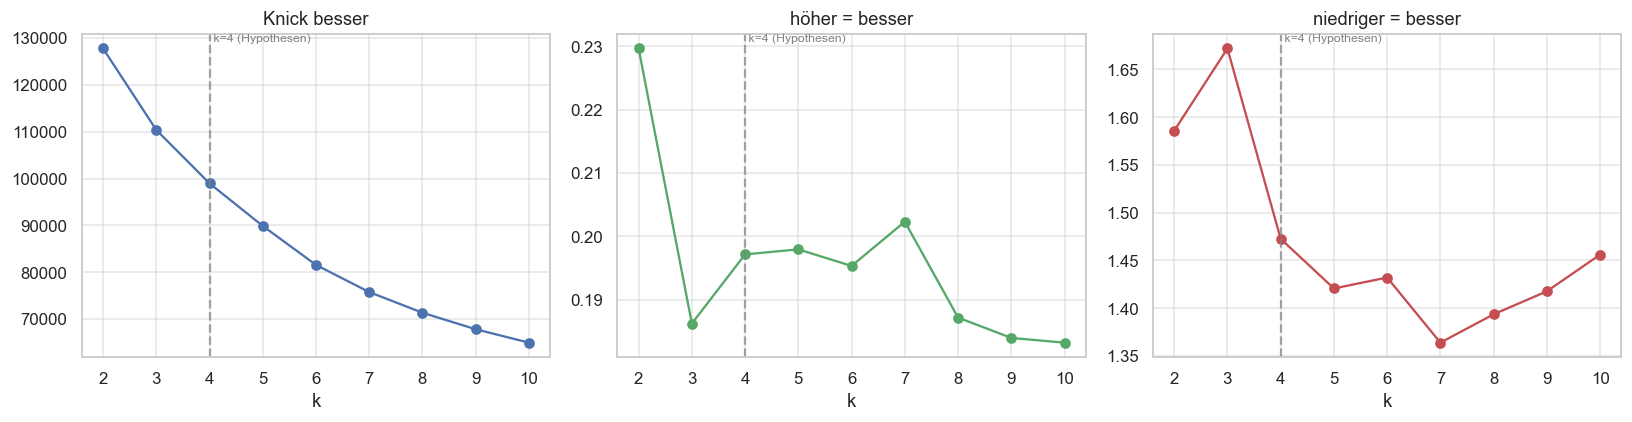

Bestes k nach Silhouette:      2
Bestes k nach Davies-Bouldin:  7


In [8]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
ax[0].plot(list(k_range), sse, "o-", color="#4C72B0"); ax[0].set_title("Knick besser") #Elbow (SSE)
ax[1].plot(list(k_range), sil, "o-", color="#55A868"); ax[1].set_title("höher = besser") # Silhouette
ax[2].plot(list(k_range), dbi, "o-", color="#C44E52"); ax[2].set_title("niedriger = besser") #  Davies-Bouldin
for a in ax:
    a.set_xlabel("k"); a.axvline(4, ls="--", c="grey", alpha=.7)
    a.text(4, a.get_ylim()[1], " k=4 (Hypothesen)", color="grey", va="top", fontsize=8)
plt.tight_layout(); plt.show()

best_sil = metrics["Silhouette"].idxmax()
best_dbi = metrics["Davies_Bouldin"].idxmin()
print(f"Bestes k nach Silhouette:      {best_sil}")
print(f"Bestes k nach Davies-Bouldin:  {best_dbi}")

In [9]:
# Finale Clusterzahl: Business-Prior (4 Segmente), im Abgleich mit den Kennzahlen oben
K = 4
print("Gewählte Clusterzahl K =", K)

Gewählte Clusterzahl K = 4


## Algorithmen-Vergleich
Für jeden Algorithmus: fitten → Cluster im PCA-Raum plotten → Kennzahlen sammeln. Density-Verfahren (DBSCAN/HDBSCAN) bestimmen die Clusterzahl selbst und markieren Ausreißer als **Noise** (Label −1).

In [10]:
from matplotlib.lines import Line2D

results = []   # Sammel-Liste für die finale Vergleichstabelle

def evaluate(name, labels):
    # Kennzahlen robust berechnen (Noise -1 ausschliessen, >=2 Cluster noetig)
    labels = np.asarray(labels)
    mask = labels != -1
    uniq = set(labels[mask])
    n_clusters = len(uniq)
    n_noise = int((labels == -1).sum())
    if n_clusters >= 2 and mask.sum() > n_clusters:
        sil = silhouette_score(X[mask], labels[mask],
                               sample_size=min(SIL_SAMPLE, mask.sum()),
                               random_state=RANDOM_STATE)
        dbi = davies_bouldin_score(X[mask], labels[mask])
    else:
        sil, dbi = np.nan, np.nan
    results.append({"Algorithmus": name, "n_Cluster": n_clusters,
                    "Noise": n_noise, "Silhouette": sil, "Davies_Bouldin": dbi})
    print(f"{name:16s} | Cluster: {n_clusters:2d} | Noise: {n_noise:5d} "
          f"| Silhouette: {sil:.3f} | DB: {dbi:.3f}")
    return labels

def plot_clusters(labels, title, emb=None, idx=None, ax=None,
                  xlabel="PC1", ylabel="PC2"):
    """Cluster in einer 2D-Projektion – feste Farbe pro Cluster, beschriftetes
    Zentrum und Legende (inkl. Größe), damit die Segmente klar erkennbar sind.

    emb : 2D-Koordinaten (default: X_pca). idx : optionale Punkt-Auswahl
    (z. B. t-SNE-Stichprobe) – dann werden labels[idx] geplottet.
    ax  : zum Einbetten in ein Grid; ohne ax wird eine eigene Figur erzeugt.
    """
    labels = np.asarray(labels)
    if emb is None:
        emb = X_pca
    if idx is not None:
        labels = labels[idx]
    own_fig = ax is None
    if own_fig:
        fig, ax = plt.subplots(figsize=(7.5, 6))

    # Cluster nach Größe: große zuerst zeichnen, kleine kommen oben drauf -> sichtbar
    clusters = sorted((c for c in np.unique(labels) if c != -1),
                      key=lambda c: (labels == c).sum(), reverse=True)
    cmap = plt.get_cmap("tab10" if len(clusters) <= 10 else "tab20")
    colors = {c: cmap(i % cmap.N) for i, c in enumerate(clusters)}

    # Noise dezent in den Hintergrund
    noise = labels == -1
    if noise.any():
        ax.scatter(emb[noise, 0], emb[noise, 1], c="lightgrey",
                   s=6, alpha=.30, linewidths=0, zorder=1)

    handles = []
    for i, c in enumerate(clusters):
        m = labels == c
        ax.scatter(emb[m, 0], emb[m, 1], color=colors[c],
                   s=14, alpha=.65, linewidths=0, zorder=2 + i)
        # Cluster-Zentrum hervorheben + beschriften (nur als Anker fürs Label)
        cx, cy = emb[m, 0].mean(), emb[m, 1].mean()
        ax.scatter(cx, cy, marker="o", s=280, color=colors[c],
                   edgecolor="black", linewidths=1.8, zorder=50)
        ax.text(cx, cy, str(c), color="black", fontsize=10, fontweight="bold",
                ha="center", va="center", zorder=51)
        handles.append(Line2D([0], [0], marker="o", linestyle="", markersize=9,
                              markerfacecolor=colors[c], markeredgecolor="black",
                              label=f"Cluster {c}  (n={int(m.sum()):,})"))
    if noise.any():
        handles.append(Line2D([0], [0], marker="o", linestyle="", markersize=9,
                              markerfacecolor="lightgrey", markeredgecolor="none",
                              label=f"Noise  (n={int(noise.sum()):,})"))

    ax.set_xlabel(xlabel); ax.set_ylabel(ylabel); ax.set_title(title)
    ax.legend(handles=handles, loc="best", framealpha=.9, fontsize=8)
    if own_fig:
        plt.tight_layout(); plt.show()

### 5.1 · K-Means

K-Means          | Cluster:  4 | Noise:     0 | Silhouette: 0.197 | DB: 1.473


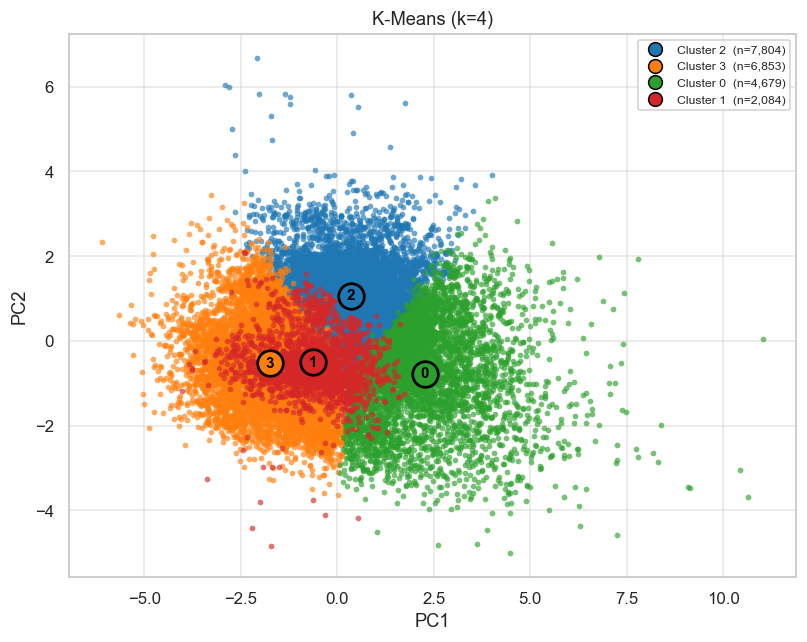

In [11]:
km = KMeans(n_clusters=K, n_init=10, random_state=RANDOM_STATE).fit(X) #4 CLuster
labels_km = evaluate("K-Means", km.labels_)
plot_clusters(labels_km, f"K-Means (k={K})")

### 5.2 · Hierarchical (Agglomerative, Ward)
Dendrogramm auf einer Zufalls-Stichprobe (Ward/Linkage ist $O(n^2)$ Speicher – für 21k unpraktisch, zur *Visualisierung* ist eine Stichprobe Standard

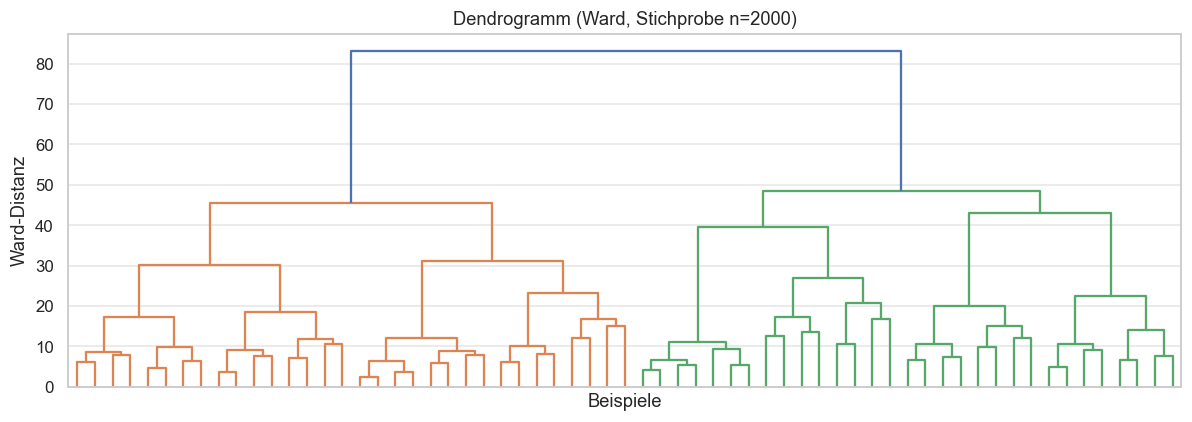

In [12]:
rng = np.random.default_rng(RANDOM_STATE)
idx = rng.choice(len(X), size=2000, replace=False)
Z = linkage(X[idx], method="ward")

plt.figure(figsize=(11, 4))
dendrogram(Z, truncate_mode="level", p=5, no_labels=True, color_threshold=None)
plt.title("Dendrogramm (Ward, Stichprobe n=2000)")
plt.xlabel("Beispiele"); plt.ylabel("Ward-Distanz")
plt.tight_layout(); plt.show()

#### Bevorzugt Ward selbst ein anderes $k$?
Der $k$-Scan ief nur mit **K-Means**. Zur Transparenz prüfen wir hier, welche Clusterzahl **Ward** über Silhouette/Davies-Bouldin bevorzugt.


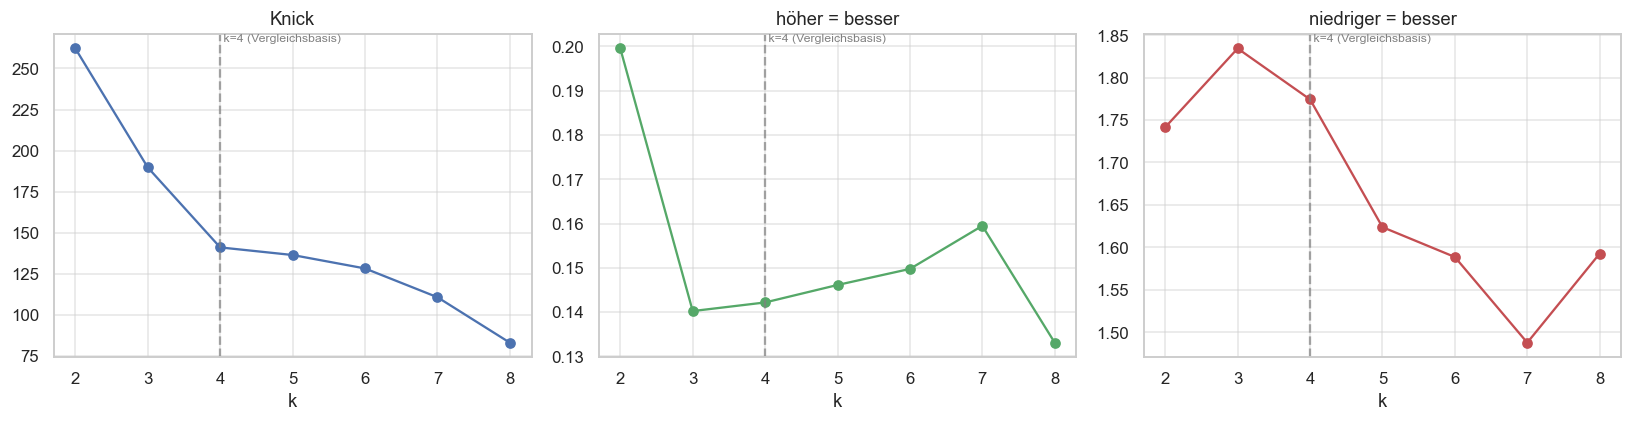

Ward-Optimum: Silhouette bei k=2, Davies-Bouldin bei k=7


k,2,3,4,5,6,7,8
Merge_Distanz,262.187,189.762,141.080,136.448,128.272,110.760,83.083
Silhouette,0.200,0.140,0.142,0.146,0.150,0.159,0.133
Davies_Bouldin,1.742,1.834,1.774,1.624,1.589,1.488,1.593


In [13]:
# Bevorzugt Ward selbst ein anderes k?
from scipy.cluster.hierarchy import fcluster

Z_full = linkage(X, method="ward")          # O(n^2) Speicher, auf 21k noch machbar
ward_k = range(2, 9)
w_sil, w_dbi = [], []
for k in ward_k:
    lab = fcluster(Z_full, t=k, criterion="maxclust")
    w_sil.append(silhouette_score(X, lab, sample_size=SIL_SAMPLE, random_state=RANDOM_STATE))
    w_dbi.append(davies_bouldin_score(X, lab))

# Ward-"Elbow": Ward hat kein SSE/Inertia wie K-Means. Das hierarchische Pendant sind
# die MERGE-DISTANZEN (Höhen im Dendrogramm) – die Distanz, bei der die Daten in k
# Cluster zerfallen. Ein Knick markiert (wie der SSE-Elbow) eine natürliche Clusterzahl.
heights_desc = np.sort(Z_full[:, 2])[::-1]
ward_merge = [heights_desc[k - 2] for k in ward_k]   # Höhe, um k Cluster zu bilden

ward_metrics = pd.DataFrame({"k": list(ward_k), "Merge_Distanz": ward_merge,
                             "Silhouette": w_sil, "Davies_Bouldin": w_dbi}).set_index("k")

fig, ax = plt.subplots(1, 3, figsize=(15, 4))
ax[0].plot(list(ward_k), ward_merge, "o-", color="#4C72B0")
ax[0].set_title("Knick")
ax[1].plot(list(ward_k), w_sil, "o-", color="#55A868")
ax[1].set_title("höher = besser") #Ward · Silhouette (
ax[2].plot(list(ward_k), w_dbi, "o-", color="#C44E52")
ax[2].set_title("niedriger = besser") #Ward · Davies-Bouldin
for a in ax:
    a.set_xlabel("k"); a.axvline(K, ls="--", c="grey", alpha=.7)
    a.text(K, a.get_ylim()[1], f" k={K} (Vergleichsbasis)", color="grey", va="top", fontsize=8)
plt.tight_layout(); plt.show()

print(f"Ward-Optimum: Silhouette bei k={ward_metrics['Silhouette'].idxmax()}, "
      f"Davies-Bouldin bei k={ward_metrics['Davies_Bouldin'].idxmin()}")
ward_metrics.T.round(3)

Hierarchical     | Cluster:  4 | Noise:     0 | Silhouette: 0.142 | DB: 1.774


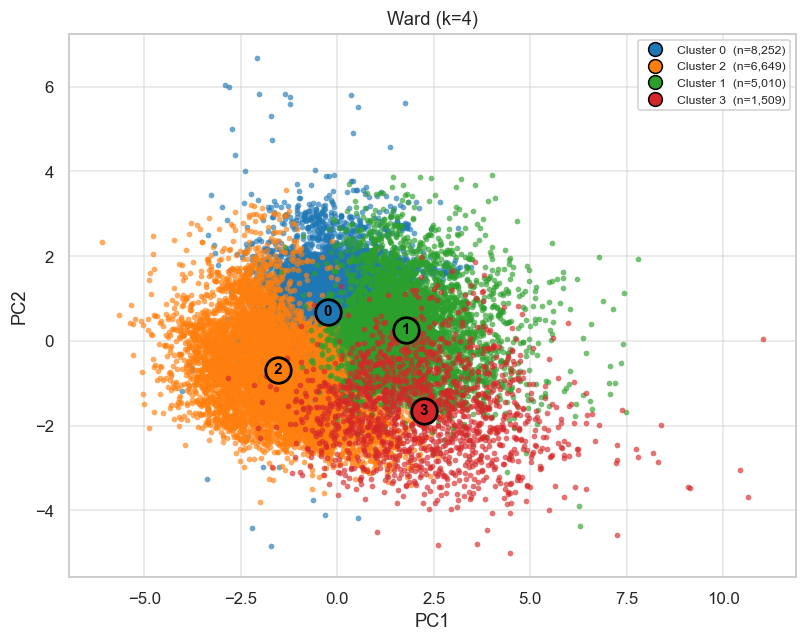

In [14]:
agg = AgglomerativeClustering(n_clusters=K, linkage="ward").fit(X)
labels_agg = evaluate("Hierarchical", agg.labels_)
plot_clusters(labels_agg, f"Ward (k={K})")

###  DBSCAN
`eps` bestimmen wir über die **k-Distance-Kurve** (Distanz zum `min_samples`-ten Nachbarn, sortiert). Der Knick markiert eine sinnvolle Nachbarschafts-Größe. Faustregel `min_samples ≈ 2 · Anzahl Features`.

min_samples = 16,  gewähltes eps = 0.360


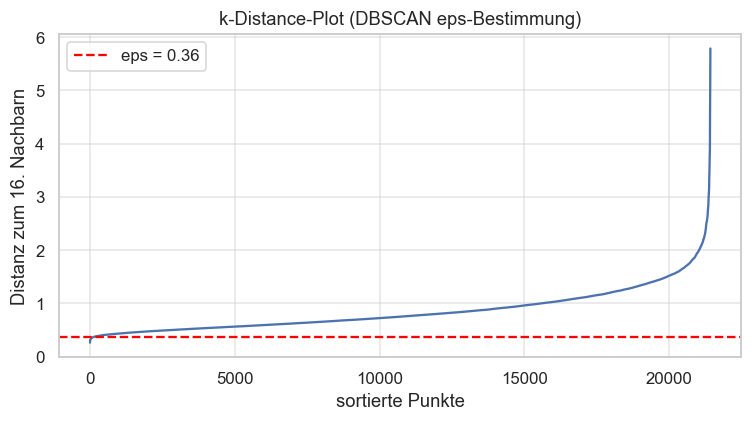

In [15]:
min_samples = 2 * X.shape[1]   # = 16
nn = NearestNeighbors(n_neighbors=min_samples).fit(X)
kdist = np.sort(nn.kneighbors(X)[0][:, -1])

# Knie = Punkt mit maximalem Abstand zur Verbindungslinie (Anfang->Ende)
x = np.arange(len(kdist))
line = np.linspace(kdist[0], kdist[-1], len(kdist))
eps = kdist[np.argmax(kdist - line)]
print(f"min_samples = {min_samples},  gewähltes eps = {eps:.3f}")

plt.figure(figsize=(7, 4))
plt.plot(x, kdist, color="#4C72B0")
plt.axhline(eps, ls="--", c="red", label=f"eps = {eps:.2f}")
plt.xlabel("sortierte Punkte"); plt.ylabel(f"Distanz zum {min_samples}. Nachbarn")
plt.title("k-Distance-Plot (DBSCAN eps-Bestimmung)"); plt.legend()
plt.tight_layout(); plt.show()

DBSCAN           | Cluster: 19 | Noise: 20883 | Silhouette: 0.406 | DB: 0.914


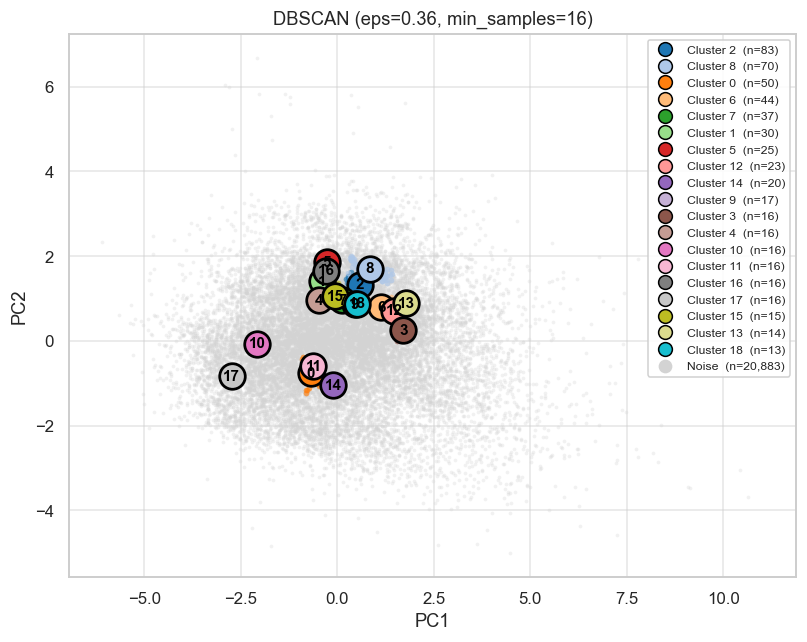

In [16]:
db = DBSCAN(eps=eps, min_samples=min_samples).fit(X)
labels_db = evaluate("DBSCAN", db.labels_)
plot_clusters(labels_db, f"DBSCAN (eps={eps:.2f}, min_samples={min_samples})")

DBSCAN           | Cluster: 19 | Noise: 20883 | Silhouette: 0.406 | DB: 0.914


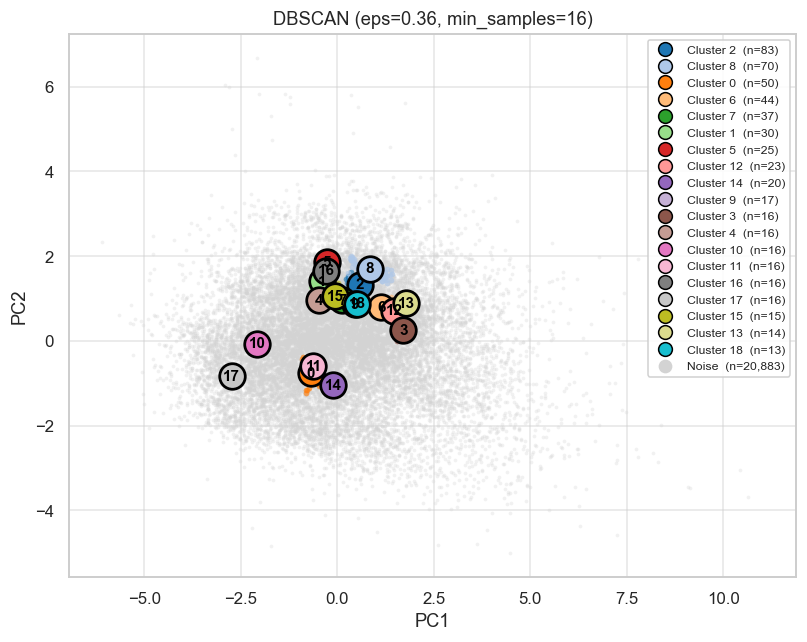

In [17]:
db = DBSCAN(eps=eps, min_samples=min_samples).fit(X)
labels_db = evaluate("DBSCAN", db.labels_)
plot_clusters(labels_db, f"DBSCAN (eps={eps:.2f}, min_samples={min_samples})")

#### Sensitivitäts-Check: Hängt der hohe Noise-Anteil an `min_samples`?
Wir haben `min_samples = 16` per Faustregel (2·Features) gewählt. Zum Test setzen wir es auf die **Untergrenze D+1 = 9** – einmal bei **festem `eps`** (isoliert den reinen `min_samples`-Effekt) und einmal mit **neu abgeleitetem `eps`** (volle Pipeline, „was wäre, wenn wir 9 von Anfang an gewählt hätten").

**Ergebnis:** Der Noise-Anteil bleibt in *allen* Varianten sehr hoch (~90–98 %) und zerfällt in noch mehr Kleinstcluster. Das bestätigt: Der hohe Noise ist **kein Parameter-Artefakt**, sondern Folge der fehlenden Dichtestruktur der Daten – DBSCAN kann hier keine vollständige Segmentierung liefern, egal wie man `min_samples` wählt.

,min_samples,eps,eps_Quelle,Cluster,Noise,Noise_%
0,16,0.360,eps fest (16er),19,20883,97.5
1,16,0.360,eps neu abgeleitet,19,20883,97.5
2,9,0.360,eps fest (16er),58,19217,89.7
3,9,0.289,eps neu abgeleitet,29,21038,98.2


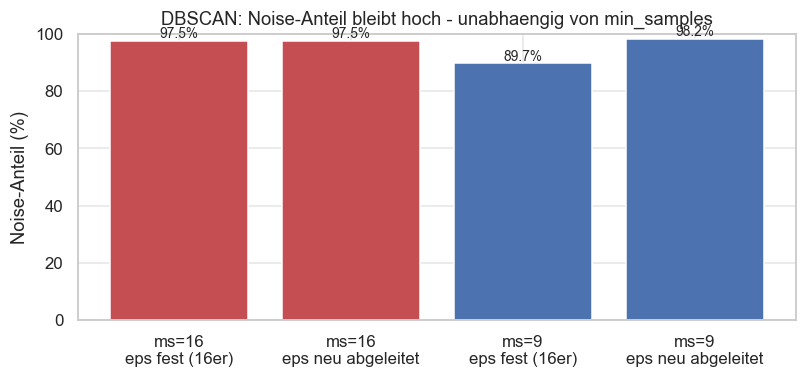

Selbst im besten Fall (~90% Noise) liefert DBSCAN keine vollstaendige Segmentierung
-> hoher Noise ist kein Parameter-Artefakt, sondern Folge fehlender Dichtestruktur.


In [18]:
# Sensitivitäts-Check: Hängt der hohe Noise-Anteil an min_samples?
# Faustregel 2*D = 16 vs. Untergrenze D+1 = 9, je einmal mit festem eps
# (isoliert den min_samples-Effekt) und mit neu abgeleitetem eps (volle Pipeline).
from sklearn.neighbors import NearestNeighbors

def eps_for(ms):
    nn = NearestNeighbors(n_neighbors=ms).fit(X)
    kd = np.sort(nn.kneighbors(X)[0][:, -1])
    line = np.linspace(kd[0], kd[-1], len(kd))
    return kd[np.argmax(kd - line)]

def dbscan_eval(ms, eps_val):
    lab = DBSCAN(eps=eps_val, min_samples=ms).fit(X).labels_
    nc = len(set(lab)) - (1 if -1 in lab else 0)
    noise = int((lab == -1).sum())
    return nc, noise, round(noise / len(X) * 100, 1)

eps_ref = eps_for(16)          # eps aus der Faustregel-Pipeline (fest halten)
rows = []
for ms in (16, 9):
    for src, e in [("eps fest (16er)", eps_ref), ("eps neu abgeleitet", eps_for(ms))]:
        nc, no, pc = dbscan_eval(ms, e)
        rows.append({"min_samples": ms, "eps": round(float(e), 3), "eps_Quelle": src,
                     "Cluster": nc, "Noise": no, "Noise_%": pc})
sens = pd.DataFrame(rows)
display(sens)

nl = chr(10)
labels_bar = [f"ms={r.min_samples}{nl}{r.eps_Quelle}" for r in sens.itertuples()]
plt.figure(figsize=(7.5, 3.6))
bars = plt.bar(labels_bar, sens["Noise_%"],
               color=["#C44E52", "#C44E52", "#4C72B0", "#4C72B0"])
plt.ylabel("Noise-Anteil (%)"); plt.ylim(0, 100)
plt.title("DBSCAN: Noise-Anteil bleibt hoch - unabhaengig von min_samples")
for b, v in zip(bars, sens["Noise_%"]):
    plt.text(b.get_x() + b.get_width() / 2, v + 1, f"{v:.1f}%", ha="center", fontsize=9)
plt.tight_layout(); plt.show()

print("Selbst im besten Fall (~90% Noise) liefert DBSCAN keine vollstaendige Segmentierung")
print("-> hoher Noise ist kein Parameter-Artefakt, sondern Folge fehlender Dichtestruktur.")


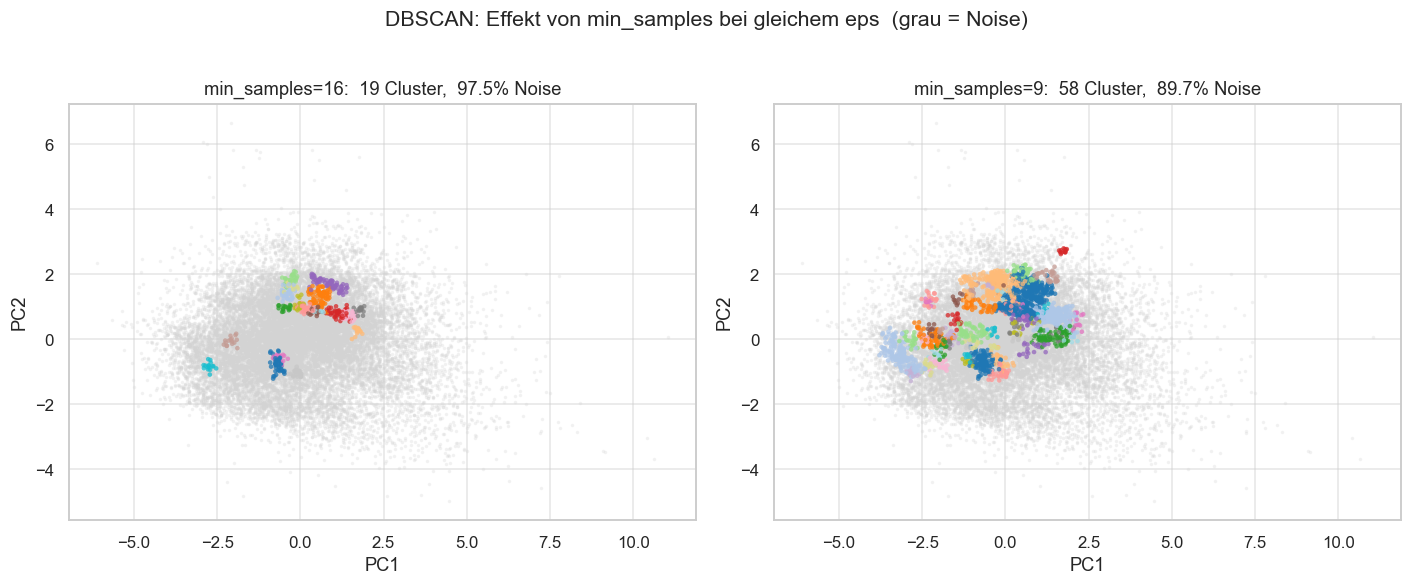

In [19]:
# Visueller Vergleich: DBSCAN-Ergebnis bei min_samples=16 vs. 9 (gleiches eps).
# Grau = Noise, farbig = einem Cluster zugeordnet. So sieht man, wie min_samples
# den Noise-Anteil und die Cluster-Zersplitterung verändert (Projektion: PCA).
def plot_dbscan_panel(ms, eps_val, ax):
    lab = DBSCAN(eps=eps_val, min_samples=ms).fit(X).labels_
    noise = lab == -1
    nc = len(set(lab)) - (1 if -1 in lab else 0)
    ax.scatter(X_pca[noise, 0], X_pca[noise, 1], c="lightgrey",
               s=5, alpha=.30, linewidths=0)
    pts = ~noise
    ax.scatter(X_pca[pts, 0], X_pca[pts, 1], c=lab[pts], cmap="tab20",
               s=9, alpha=.75, linewidths=0)
    ax.set_title(f"min_samples={ms}:  {nc} Cluster,  {noise.mean() * 100:.1f}% Noise")
    ax.set_xlabel("PC1"); ax.set_ylabel("PC2")

fig, axes = plt.subplots(1, 2, figsize=(13, 5.2))
plot_dbscan_panel(16, eps_ref, axes[0])   # Faustregel
plot_dbscan_panel(9, eps_ref, axes[1])    # Untergrenze D+1, gleiches eps
fig.suptitle("DBSCAN: Effekt von min_samples bei gleichem eps  (grau = Noise)",
             fontsize=14, y=1.02)
plt.tight_layout(); plt.show()


#### Parameter-Diagnose: welche Stellschrauben hat DBSCAN? (durchgespielt)

DBSCAN hat effektiv **nur zwei** Parameter (plus das Distanzmass `metric`, hier euklidisch):

- **`eps`** — Radius der Nachbarschaft. **Der Haupt-Hebel.** Zu klein → fast alles wird *Noise* bzw. zerfaellt in viele Mini-Cluster; zu gross → alle Punkte verschmelzen zu **einem** Cluster.
- **`min_samples`** — wie viele Nachbarn ein Punkt im `eps`-Radius braucht, um *Kernpunkt* zu sein. Groesser → strenger → **mehr Noise**. Faustregel `2 x Features = 16`.

Statt einzelner Werte spielen wir hier den **ganzen Bereich** durch: `eps` von `auto_eps` (dem Knick der k-Distance-Kurve) bis zum 95%-Perzentil, fuer drei `min_samples`-Werte. Beobachtung: Es gibt **kein** Paar `(eps, min_samples)`, das gleichzeitig wenig Noise *und* mehrere sinnvolle Cluster liefert — die Silhouette bleibt durchweg &le; 0.

In [ ]:
# Parameter-Sweep DBSCAN: "durchspielen" der beiden einzigen Stellschrauben.
#   eps         (x-Achse) -> Nachbarschaftsradius. Klein = viel Noise/viele Mini-Cluster,
#                            gross = alles verschmilzt zu EINEM Cluster.
#   min_samples (Kurven)  -> wie viele Nachbarn ein Kernpunkt braucht. Gross = mehr Noise.
# Silhouette wird im echten Feature-Raum X gemessen (Noise -1 ausgeschlossen).

def _sil_X(labels):
    labels = np.asarray(labels)
    m = labels != -1
    if len(set(labels[m].tolist())) < 2:      # <2 Cluster -> Silhouette undefiniert
        return np.nan
    try:
        return silhouette_score(X[m], labels[m],
                                sample_size=min(SIL_SAMPLE, int(m.sum())),
                                random_state=RANDOM_STATE)
    except ValueError:
        return np.nan

# eps-Raster aus der k-Distance-Verteilung ableiten (ms=16 wie in §5.3):
# von auto_eps (dem Knick) bis zum 95%-Perzentil -> deckt "zu klein" bis "zu gross" ab.
_nn = NearestNeighbors(n_neighbors=16).fit(X)
_kd = np.sort(_nn.kneighbors(X)[0][:, -1])
_line = np.linspace(_kd[0], _kd[-1], len(_kd))
auto_eps = float(_kd[np.argmax(_kd - _line)])
eps_grid = np.round(np.linspace(auto_eps, np.percentile(_kd, 95), 7), 2)
ms_curves = [5, 16, 32]                        # min_samples-Kurven

fig, ax = plt.subplots(1, 3, figsize=(16, 4.2))
for ms in ms_curves:
    ks, noises, sils = [], [], []
    for e in eps_grid:
        lab = DBSCAN(eps=float(e), min_samples=ms).fit(X).labels_
        ks.append(len(set(lab.tolist()) - {-1}))
        noises.append((lab == -1).mean() * 100)
        sils.append(_sil_X(lab))
    ax[0].plot(eps_grid, ks,     "o-", label=f"min_samples={ms}")
    ax[1].plot(eps_grid, noises, "o-", label=f"min_samples={ms}")
    ax[2].plot(eps_grid, sils,   "o-", label=f"min_samples={ms}")

for a in ax:
    a.axvline(auto_eps, ls="--", color="grey", lw=1)
    a.legend(fontsize=8)
ax[0].text(auto_eps, ax[0].get_ylim()[1], " auto_eps", color="grey", va="top", fontsize=8)
ax[0].set(title="Anzahl gefundener Cluster", xlabel="eps", ylabel="n_Cluster")
ax[1].set(title="Noise-Anteil", xlabel="eps", ylabel="% als Noise markiert")
ax[2].axhline(0, color="black", lw=.7)
ax[2].set(title="Silhouette (gemessen auf X)", xlabel="eps", ylabel="Silhouette")
fig.suptitle("DBSCAN-Parameter-Sweep auf X: wie eps & min_samples das Ergebnis steuern",
             fontsize=14, y=1.03)
plt.tight_layout()
plt.show()

print(f"auto_eps (Knick, min_samples=16) = {auto_eps:.2f}")
print("Lesart: kleines eps -> viele Mini-Cluster + viel Noise; grosses eps -> alles")
print("        verschmilzt zu k=1. Die Silhouette bleibt ueberall <= 0 -> es gibt KEIN")
print("        (eps, min_samples), das eine saubere Mehr-Cluster-Partition liefert.")
print("        -> bestaetigt: keine Dichtestruktur, der Markt ist ein Kontinuum.")


#### k = 2..10 bei DBSCAN? — DBSCAN auf die Ziel-Clusterzahl gebracht

Anders als K-Means/GMM kennt **DBSCAN kein `k`** — die Clusterzahl ergibt sich aus `eps` und `min_samples`. Um trotzdem dieselbe `k = 2..10`-Perspektive zu bekommen halten wir `min_samples` fest (= 16) und **suchen je Ziel-`k` das `eps`, das dieser Clusterzahl am nächsten kommt** (analog zu `hdbscan_to_k()`).


In [ ]:
def _sil_X_db(labels):
    """Silhouette im echten 8-Feature-Raum X (Noise -1 ausgeschlossen)."""
    labels = np.asarray(labels)
    m = labels != -1
    if len(set(labels[m].tolist())) < 2:      # <2 Cluster -> Silhouette undefiniert
        return np.nan
    try:
        return silhouette_score(X[m], labels[m],
                                sample_size=min(SIL_SAMPLE, int(m.sum())),
                                random_state=RANDOM_STATE)
    except ValueError:
        return np.nan

_ms_db = 2 * X.shape[1]                        # = 16, gleiche min_samples-Wahl wie in 5.3

# Feines eps-Raster aus der k-Distance-Verteilung: von "klein" (viele Mini-Cluster
# + viel Noise) bis "gross" (alles verschmilzt zu k=1). Dazwischen liegen die eps,
# die 2..10 Cluster erzeugen - falls es sie ueberhaupt gibt.
_nn_db = NearestNeighbors(n_neighbors=_ms_db).fit(X)
_kd_db = np.sort(_nn_db.kneighbors(X)[0][:, -1])
eps_scan = np.linspace(np.percentile(_kd_db, 30), np.percentile(_kd_db, 99.5), 45)

# Einmal ueber das ganze eps-Raster scannen und je eps k / Noise / Silhouette merken.
db_runs = []
for e in eps_scan:
    lab = DBSCAN(eps=float(e), min_samples=_ms_db).fit(X).labels_
    db_runs.append({"eps": float(e),
                    "k": len(set(lab.tolist()) - {-1}),
                    "noise": float((lab == -1).mean()),
                    "sil": _sil_X_db(lab)})
db_runs = pd.DataFrame(db_runs)

# Fuer jede Ziel-Clusterzahl die eps-Konfiguration waehlen, die ihr am naechsten
# kommt (Tie-Break: weniger Noise) - das ist das DBSCAN-Pendant zu "gib mir k Cluster".
rows = []
for target in range(2, 11):
    cand = db_runs.assign(dist=(db_runs["k"] - target).abs())
    best = cand.sort_values(["dist", "noise"]).iloc[0]
    rows.append({"Ziel_k": target,
                 "erreichtes_k": int(best["k"]),
                 "getroffen": "ja" if int(best["k"]) == target else "nein",
                 "eps": round(float(best["eps"]), 3),
                 "min_samples": _ms_db,
                 "Noise_%": round(best["noise"] * 100, 1),
                 "Silhouette_auf_X": round(best["sil"], 3) if pd.notna(best["sil"]) else np.nan})
dbscan_k_table = pd.DataFrame(rows).set_index("Ziel_k")

# --- Visualisierung: 3 Panels ueber die Ziel-Clusterzahl 2..10 ---
tk = dbscan_k_table.index.to_numpy()
fig, ax = plt.subplots(1, 3, figsize=(16, 4.2))
ax[0].plot(tk, tk, "--", color="grey", lw=1, label="ideal (erreicht = Ziel)")
ax[0].plot(tk, dbscan_k_table["erreichtes_k"], "o-", color="#4C72B0", label="tatsaechlich erreicht")
ax[0].set(title="Erreichte vs. gewuenschte Clusterzahl", xlabel="Ziel-k", ylabel="erreichtes k")
ax[0].legend(fontsize=8)
ax[1].plot(tk, dbscan_k_table["Noise_%"], "o-", color="#C44E52")
ax[1].set(title="Noise-Anteil bei der besten eps-Wahl", xlabel="Ziel-k", ylabel="% als Noise")
ax[2].axhline(0, color="black", lw=.7)
ax[2].plot(tk, dbscan_k_table["Silhouette_auf_X"], "o-", color="#55A868")
ax[2].set(title="Silhouette (auf X) der DBSCAN-Loesung", xlabel="Ziel-k", ylabel="Silhouette")
fig.suptitle("DBSCAN 'auf k=2..10 gebracht': eps getunt, min_samples fix = %d" % _ms_db,
             fontsize=14, y=1.03)
plt.tight_layout()
plt.show()

print("DBSCAN auf Ziel-Clusterzahl gebracht (min_samples fix = %d):" % _ms_db)
print(dbscan_k_table)
print("\nLesart: DBSCAN kennt kein k - wir treffen die Zielzahl nur, indem wir eps drehen.")
print("Wo 'getroffen=nein' steht, gibt es schlicht KEIN eps, das genau so viele Cluster")
print("liefert (k springt von vielen Mini-Clustern direkt zu k=1). Und die Silhouette-auf-X")
print("bleibt durchweg <= 0 -> auch 'auf k gezwungen' findet DBSCAN keine saubere Partition")
print("-> bestaetigt erneut: keine Dichtestruktur, der Markt ist ein Kontinuum.")


### 5.4 · HDBSCAN
Erweitert DBSCAN über verschiedene Dichte-Skalen und braucht kein festes `eps` Wir steuern nur die minimale Clustergröße.

C:\Users\Schne\PyCharmMiscProject\.venv\Lib\site-packages\sklearn\cluster\_hdbscan\hdbscan.py:722: FutureWarning: The default value of `copy` will change from False to True in 1.10. Explicitly set a value for `copy` to silence this warning.
  warn(


HDBSCAN          | Cluster:  5 | Noise:  4707 | Silhouette: 0.044 | DB: 2.120


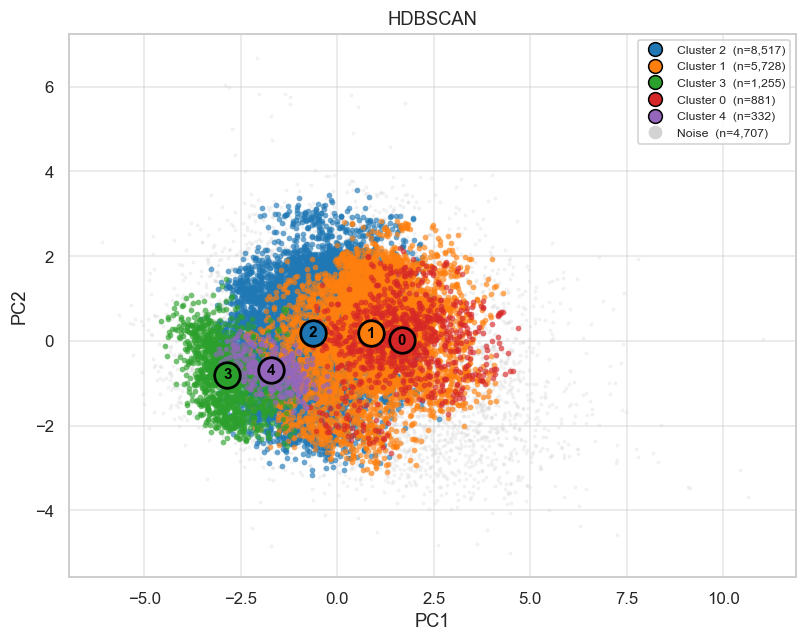

In [20]:
hdb = HDBSCAN(min_cluster_size=250, min_samples=15).fit(X)
labels_hdb = evaluate("HDBSCAN", hdb.labels_)
plot_clusters(labels_hdb, "HDBSCAN")

### 5.5 · Gaussian Mixture Model
Weiche Zuordnung über Mischverteilungen. Die Komponentenzahl wählen wir über den **BIC** (niedriger = besser)

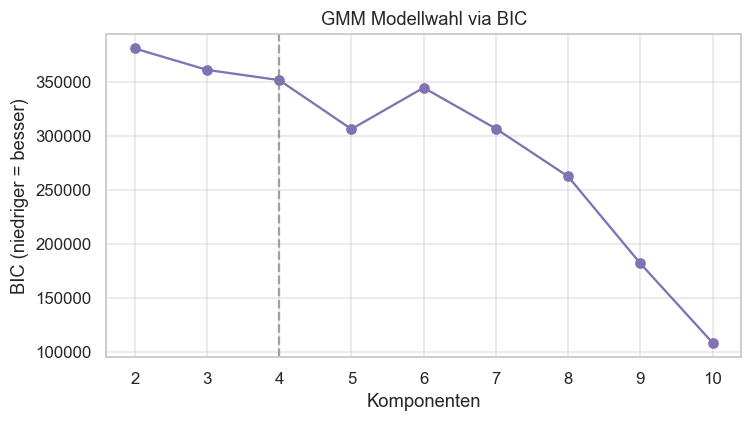

Bestes n nach BIC: 10 | wir clustern zusätzlich mit K = 4


In [21]:
bic = []
comp_range = range(2, 11)
for n in comp_range:
    gm = GaussianMixture(n_components=n, covariance_type="full",
                         random_state=RANDOM_STATE).fit(X)
    bic.append(gm.bic(X))

plt.figure(figsize=(7, 4))
plt.plot(list(comp_range), bic, "o-", color="#8172B3")
plt.axvline(4, ls="--", c="grey", alpha=.7)
plt.xlabel("Komponenten"); plt.ylabel("BIC (niedriger = besser)")
plt.title("GMM Modellwahl via BIC"); plt.tight_layout(); plt.show()

best_gmm = list(comp_range)[int(np.argmin(bic))]
print("Bestes n nach BIC:", best_gmm, "| wir clustern zusätzlich mit K =", K)

GMM              | Cluster:  4 | Noise:     0 | Silhouette: 0.072 | DB: 2.384


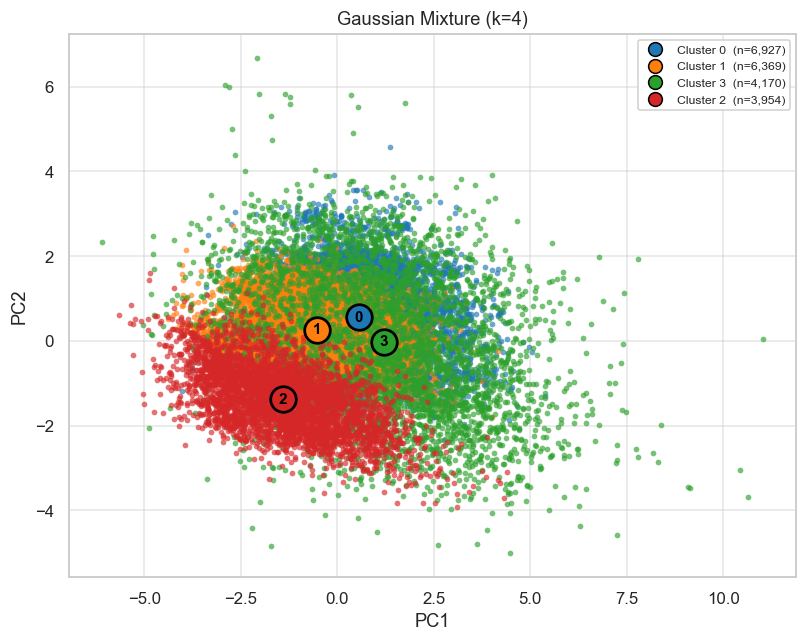

In [22]:
gmm = GaussianMixture(n_components=K, covariance_type="full",
                      random_state=RANDOM_STATE).fit(X)
labels_gmm = evaluate("GMM", gmm.predict(X))
plot_clusters(labels_gmm, f"Gaussian Mixture (k={K})")

#### Kennzahlen ueber k = 2..10: K-Means vs. GMM

K-Means und GMM sind die beiden **partitionierenden** Verfahren, die ein `k` brauchen. §4 hat den k-Scan nur fuer K-Means gezeigt; hier stellen wir **beide ueber `k = 2,3,4,5,6,7,8,9,10` gegenueber** (Silhouette, Davies-Bouldin und das modell-eigene Kriterium: SSE-Elbow bzw. GMM-BIC). Die graue Linie markiert unseren Business-Prior `k=4`. So sieht man auf einen Blick, ob ein anderes `k` statistisch klar besser waere - ist es nicht: die Kurven sind flach/monoton, es gibt kein scharfes Optimum. Damit bleibt die **inhaltliche** Wahl `k=4` gerechtfertigt.

In [ ]:
# Kennzahlen der PARTITIONIERENDEN Verfahren ueber k = 2..10 (K-Means vs. GMM).
# Ergaenzt  (dort nur K-Means) um GMM und stellt beide direkt gegenueber,
# um k=4 und die Wahl von K-Means zu begruenden.
# KEIN evaluate() -> die Haupt-Vergleichstabelle (results) bleibt unberuehrt.
from sklearn.metrics import davies_bouldin_score

def _silx(labels):
    labels = np.asarray(labels)
    if len(set(labels.tolist())) < 2:
        return np.nan
    return silhouette_score(X, labels, sample_size=min(SIL_SAMPLE, len(X)),
                            random_state=RANDOM_STATE)

k_scan = range(2, 11)                     # k = 2,3,4,5,6,7,8,9,10
km_sil, km_dbi, km_sse = [], [], []
gm_sil, gm_dbi, gm_bic = [], [], []
for k in k_scan:
    km = KMeans(n_clusters=k, n_init=10, random_state=RANDOM_STATE).fit(X)
    km_sil.append(_silx(km.labels_))
    km_dbi.append(davies_bouldin_score(X, km.labels_))
    km_sse.append(km.inertia_)
    gm = GaussianMixture(n_components=k, covariance_type="full",
                         random_state=RANDOM_STATE).fit(X)
    gl = gm.predict(X)
    gm_sil.append(_silx(gl))
    gm_dbi.append(davies_bouldin_score(X, gl))
    gm_bic.append(gm.bic(X))

ks = list(k_scan)
fig, ax = plt.subplots(1, 3, figsize=(16, 4.2))
ax[0].plot(ks, km_sil, "o-", label="K-Means")
ax[0].plot(ks, gm_sil, "s--", label="GMM")
ax[0].set(title="Silhouette (hoeher = besser)", xlabel="k", ylabel="Silhouette")
ax[1].plot(ks, km_dbi, "o-", label="K-Means")
ax[1].plot(ks, gm_dbi, "s--", label="GMM")
ax[1].set(title="Davies-Bouldin (niedriger = besser)", xlabel="k", ylabel="DBI")
# Panel 3: modell-eigene Kriterien (unterschiedliche Skalen -> Twin-Achsen)
l1, = ax[2].plot(ks, km_sse, "o-", color="#4C72B0", label="K-Means SSE")
ax[2].set(title="Modell-eigenes Kriterium", xlabel="k", ylabel="K-Means SSE (Inertia)")
ax2b = ax[2].twinx()
l2, = ax2b.plot(ks, gm_bic, "s--", color="#C44E52", label="GMM BIC")
ax2b.set_ylabel("GMM BIC")
ax[2].legend(handles=[l1, l2], fontsize=8, loc="upper right")
for a in (ax[0], ax[1], ax[2]):
    a.axvline(4, ls="--", color="grey", lw=1)
ax[0].legend(fontsize=8); ax[1].legend(fontsize=8)
fig.suptitle("Partitionierende Verfahren: Kennzahlen ueber k = 2..10 (K-Means vs. GMM)",
             fontsize=14, y=1.03)
plt.tight_layout()
plt.show()

ktab = pd.DataFrame({"k": ks, "KM_Silhouette": km_sil, "KM_DaviesB": km_dbi,
                     "GMM_Silhouette": gm_sil, "GMM_DaviesB": gm_dbi}).set_index("k").round(3)
print(ktab)
print("\nLesart: k=4 ist der Business-Prior (vier Kaeufer-Hypothesen). Die Kurven zeigen,")
print("dass k=4 kein scharfes statistisches Optimum ist (Silhouette faellt mit k, DBI flach),")
print("aber vertretbar bleibt - die Entscheidung faellt ueber das PROBLEM, nicht die Kennzahl.")


### t-SNE-Projektion (nichtlinear, nur zur Visualisierung)
PC1/PC2 fangen nur einen Teil der Varianz ein, weshalb die Cluster im PCA-Bild stark überlappen. **t-SNE** ist eine nichtlineare Projektion, die lokale Nachbarschaften erhält und die Segmente optisch meist deutlich klarer trennt.

Wie die PCA dient t-SNE **nur der Visualisierung** – geclustert wird weiterhin auf allen 8 Features. Wichtig: t-SNE-Achsen und -Abstände sind **nicht** quantitativ interpretierbar (keine feste Bedeutung, kein „größer = teurer"), sie zeigen nur, *ob* sich Gruppen sauber separieren lassen.

t-SNE berechnet für 21420 Punkte


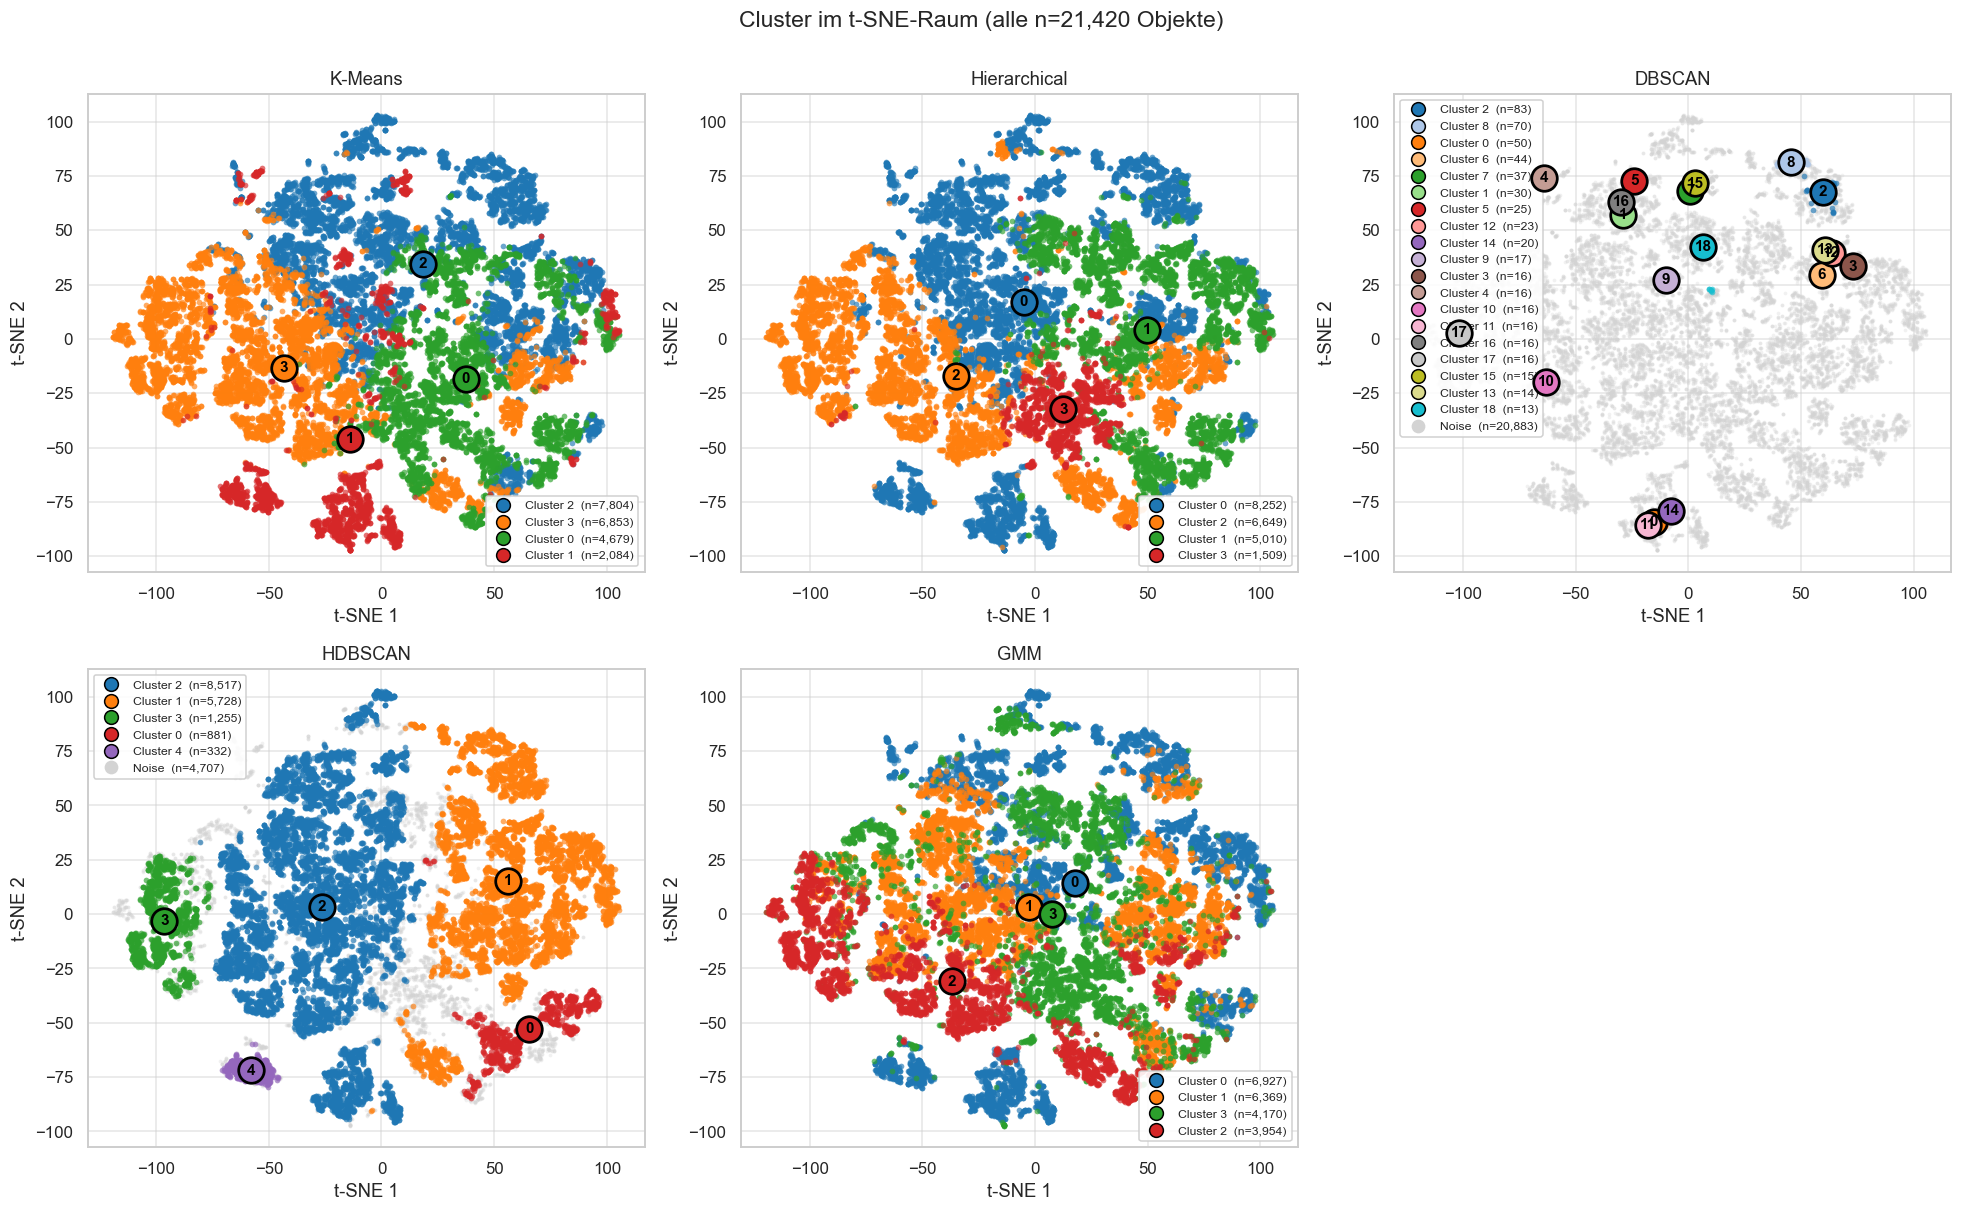

In [23]:
from sklearn.manifold import TSNE

# Visualisierung auf ALLEN 21.420 Objekten (kein Subsampling).
# Für einen schnelleren Lauf stattdessen eine Stichprobe ziehen, z. B.:
#   tsne_idx = np.random.default_rng(RANDOM_STATE).choice(len(X), size=6000, replace=False)
tsne_idx = np.arange(len(X))          # alle Punkte

# t-SNE ist rechenintensiv -> Fit auf 21k dauert ~30-40 s.
X_tsne = TSNE(n_components=2, perplexity=30, init="pca",
              learning_rate="auto", random_state=RANDOM_STATE).fit_transform(X[tsne_idx])
print("t-SNE berechnet für", len(tsne_idx), "Punkte")

# Alle Verfahren im t-SNE-Raum nebeneinander (gleiche Labels, bessere Trennung)
runs = [("K-Means", labels_km), ("Hierarchical", labels_agg), ("DBSCAN", labels_db),
        ("HDBSCAN", labels_hdb), ("GMM", labels_gmm)]

fig, axes = plt.subplots(2, 3, figsize=(18, 11))
for ax, (name, lab) in zip(axes.ravel(), runs):
    plot_clusters(lab, name, emb=X_tsne, idx=tsne_idx, ax=ax,
                  xlabel="t-SNE 1", ylabel="t-SNE 2")
axes.ravel()[-1].axis("off")   # 6. Feld leer lassen
fig.suptitle(f"Cluster im t-SNE-Raum (alle n={len(tsne_idx):,} Objekte)",
             fontsize=15, y=1.0)
plt.tight_layout(); plt.show()

### UMAP-Projektion (Vergleich zu t-SNE)
**UMAP** ist eine zweite nichtlineare Projektion. Gegenüber t-SNE erhält es neben der lokalen auch die **globale** Struktur meist besser (Abstände zwischen Clustern sind etwas aussagekräftiger) und ist schneller. Wir rechnen es auf **denselben Punkten** (allen 21.420) wie t-SNE, damit der Vergleich fair ist.


C:\Users\Schne\PyCharmMiscProject\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


UMAP berechnet für 21420 Punkte


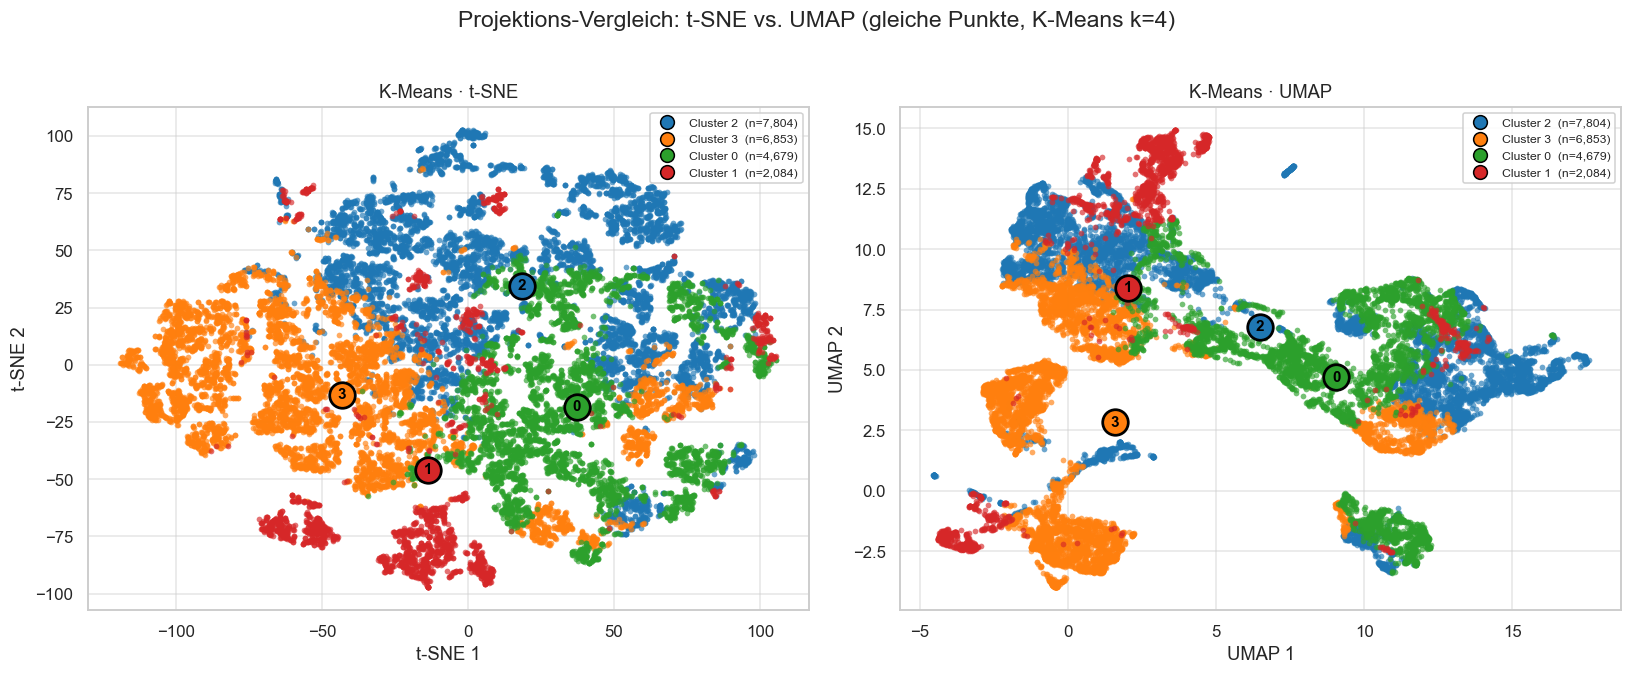

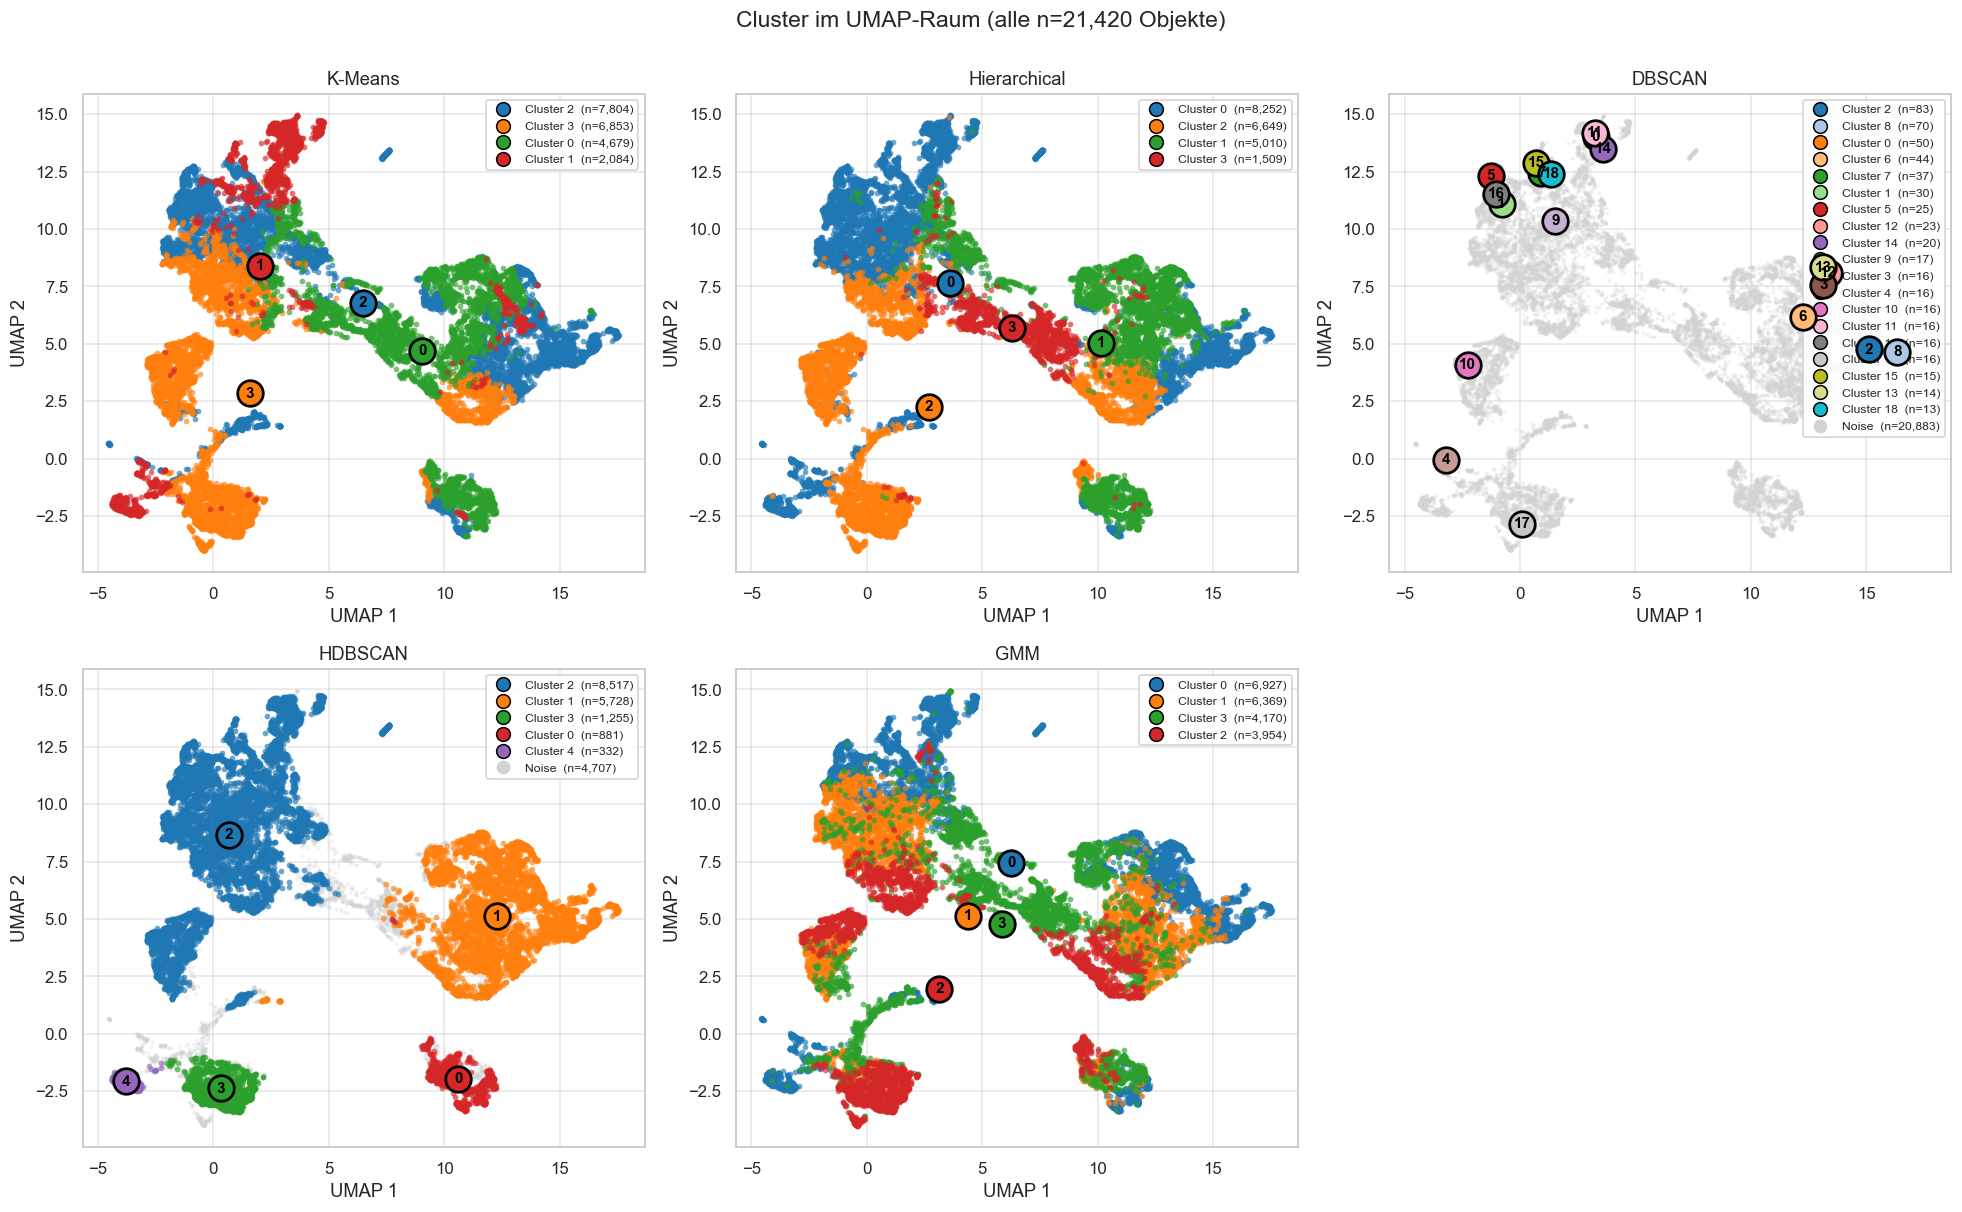

In [24]:
import warnings
import umap

# Gleiche Punkte (tsne_idx = alle 21.420) wie t-SNE -> fairer Direktvergleich.
# UMAP-Fit auf 21k dauert ~40-60 s.
with warnings.catch_warnings():
    warnings.simplefilter("ignore")   # numba-/UMAP-Hinweise unterdrücken
    X_umap = umap.UMAP(n_neighbors=15, min_dist=0.1, n_components=2,
                       random_state=RANDOM_STATE).fit_transform(X[tsne_idx])
print("UMAP berechnet für", len(tsne_idx), "Punkte")

# a) Direktvergleich der beiden Projektionen am gewählten Verfahren (K-Means, k=4)
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
plot_clusters(labels_km, "K-Means · t-SNE", emb=X_tsne, idx=tsne_idx, ax=axes[0],
              xlabel="t-SNE 1", ylabel="t-SNE 2")
plot_clusters(labels_km, "K-Means · UMAP", emb=X_umap, idx=tsne_idx, ax=axes[1],
              xlabel="UMAP 1", ylabel="UMAP 2")
fig.suptitle(f"Projektions-Vergleich: t-SNE vs. UMAP (gleiche Punkte, K-Means k={K})",
             fontsize=15, y=1.02)
plt.tight_layout(); plt.show()

# b) Alle Verfahren im UMAP-Raum (Pendant zum t-SNE-Grid oben; runs von dort wiederverwendet)
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
for ax, (name, lab) in zip(axes.ravel(), runs):
    plot_clusters(lab, name, emb=X_umap, idx=tsne_idx, ax=ax,
                  xlabel="UMAP 1", ylabel="UMAP 2")
axes.ravel()[-1].axis("off")
fig.suptitle(f"Cluster im UMAP-Raum (alle n={len(tsne_idx):,} Objekte)", fontsize=15, y=1.0)
plt.tight_layout(); plt.show()

### 5.8 · HDBSCAN gezielt auf ~4 Cluster gebracht (auf X vs. auf dem Embedding)

Oben laesst HDBSCAN die Clusterzahl frei und produziert auf den 8 Features sehr viel Noise. Hier bringen wir es **bewusst in Richtung 4 Segmente** und vergleichen zwei Wege:

- **A — auf allen 8 Features (`X`):** methodisch konsistent zur eigentlichen Segmentierung. Wir tunen nur `min_cluster_size` (groessere Mindestgroesse -> groebere, weniger Cluster) Richtung `k=4`.
- **B — direkt auf dem 2D-Embedding (t-SNE / UMAP):** die Projektion ist dicht und gut separiert, HDBSCAN findet dort fast immer saubere, kompakte Cluster und laesst sich leicht auf ~4 steuern. **Aber:** hier wird auf der *Projektion* geclustert, nicht auf den echten Features — Achsen/Abstaende sind nicht inhaltlich interpretierbar. Das ist eine **bewusste Zusatz-Analyse**, nicht die Haupt-Segmentierung.

Damit A und B fair vergleichbar bleiben, messen wir die **Silhouette bei beiden im echten 8-Feature-Raum `X`** (nicht im Embedding).

In [25]:
def hdbscan_to_k(data, target=K, min_samples=10,
                 sizes=(250, 400, 600, 900, 1400, 1600, 2000, 3000)):
    """Sucht die min_cluster_size, deren HDBSCAN-Ergebnis der Ziel-Clusterzahl am
    naechsten kommt (Tie-Break: weniger Noise). Gibt beste Wahl + alle Laeufe zurueck.
    HDBSCAN waehlt selbst, WIE VIELE Cluster; wir steuern nur ueber die minimale
    Clustergroesse, wie grob/fein aufgeloest wird -> so naehern wir uns k=4 an."""
    runs = []
    for mcs in sizes:
        lab = HDBSCAN(min_cluster_size=int(mcs), min_samples=min_samples).fit(data).labels_
        k = len(set(lab) - {-1})
        noise = float((lab == -1).mean())
        runs.append({"mcs": int(mcs), "k": k, "noise": noise, "labels": lab})
    runs.sort(key=lambda r: (abs(r["k"] - target), r["noise"]))
    return runs[0], runs

def sil_on_X(labels):
    """Silhouette IMMER im echten Feature-Raum X berechnen (fairer, vergleichbarer
    Massstab) - egal, worauf geclustert wurde. Noise (-1) ausgeschlossen."""
    labels = np.asarray(labels)
    m = labels != -1
    if len(set(labels[m].tolist())) < 2:
        return np.nan
    return silhouette_score(X[m], labels[m],
                            sample_size=min(SIL_SAMPLE, int(m.sum())),
                            random_state=RANDOM_STATE)

# --- A) HDBSCAN auf X (8 Features), Richtung k=4 getunt ---
bestA, sweepA = hdbscan_to_k(X)
labels_hdb_X = bestA["labels"]

# --- B) HDBSCAN auf den 2D-Projektionen, ebenfalls Richtung k=4 ---
bestT, sweepT = hdbscan_to_k(X_tsne)
labels_hdb_tsne = bestT["labels"]
bestU, sweepU = hdbscan_to_k(X_umap)
labels_hdb_umap = bestU["labels"]

hdb_summary = pd.DataFrame([
    {"Variante": "A - HDBSCAN auf X (8 Feat.)", "min_cluster_size": bestA["mcs"],
     "n_Cluster": bestA["k"], "Noise_%": round(bestA["noise"] * 100, 1),
     "Silhouette_auf_X": sil_on_X(labels_hdb_X)},
    {"Variante": "B - HDBSCAN auf t-SNE (2D)", "min_cluster_size": bestT["mcs"],
     "n_Cluster": bestT["k"], "Noise_%": round(bestT["noise"] * 100, 1),
     "Silhouette_auf_X": sil_on_X(labels_hdb_tsne)},
    {"Variante": "B - HDBSCAN auf UMAP (2D)", "min_cluster_size": bestU["mcs"],
     "n_Cluster": bestU["k"], "Noise_%": round(bestU["noise"] * 100, 1),
     "Silhouette_auf_X": sil_on_X(labels_hdb_umap)},
]).set_index("Variante").round(3)

print("Zielclusterzahl:", K)
print(hdb_summary)
print("\nHinweis: Silhouette wird bei allen Varianten im echten 8-Feature-Raum X gemessen,")
print("damit A und B vergleichbar sind - auch wenn B auf der 2D-Projektion geclustert hat.")


C:\Users\Schne\PyCharmMiscProject\.venv\Lib\site-packages\sklearn\cluster\_hdbscan\hdbscan.py:722: FutureWarning: The default value of `copy` will change from False to True in 1.10. Explicitly set a value for `copy` to silence this warning.
  warn(
C:\Users\Schne\PyCharmMiscProject\.venv\Lib\site-packages\sklearn\cluster\_hdbscan\hdbscan.py:722: FutureWarning: The default value of `copy` will change from False to True in 1.10. Explicitly set a value for `copy` to silence this warning.
  warn(
C:\Users\Schne\PyCharmMiscProject\.venv\Lib\site-packages\sklearn\cluster\_hdbscan\hdbscan.py:722: FutureWarning: The default value of `copy` will change from False to True in 1.10. Explicitly set a value for `copy` to silence this warning.
  warn(
C:\Users\Schne\PyCharmMiscProject\.venv\Lib\site-packages\sklearn\cluster\_hdbscan\hdbscan.py:722: FutureWarning: The default value of `copy` will change from False to True in 1.10. Explicitly set a value for `copy` to silence this warning.
  warn(
C:\U

Zielclusterzahl: 4
                             min_cluster_size  n_Cluster  Noise_%  \
Variante                                                            
A - HDBSCAN auf X (8 Feat.)               400          4     16.2   
B - HDBSCAN auf t-SNE (2D)                600          4      6.8   
B - HDBSCAN auf UMAP (2D)                1600          4      8.1   

                             Silhouette_auf_X  
Variante                                       
A - HDBSCAN auf X (8 Feat.)             0.068  
B - HDBSCAN auf t-SNE (2D)             -0.057  
B - HDBSCAN auf UMAP (2D)               0.036  

Hinweis: Silhouette wird bei allen Varianten im echten 8-Feature-Raum X gemessen,
damit A und B vergleichbar sind - auch wenn B auf der 2D-Projektion geclustert hat.


#### Parameter-Diagnose: welche Stellschrauben hat HDBSCAN?

Anders als K-Means bekommt HDBSCAN **kein `k`** vorgegeben — es bestimmt die Clusterzahl selbst. Deshalb gibt es keine "Silhouette ueber k"-Kurve. Die passende Diagnose ist stattdessen: **wie steuern die Parameter das Ergebnis?**

- **`min_cluster_size`** (x-Achse) — kleinste Gruppe, die als Cluster zaehlt. Groesser → weniger, groebere Cluster (Richtung k=4).
- **`min_samples`** (die drei Kurven) — wie schnell Punkte als *Noise* gelten. Groesser → mehr Noise, nur dichte Kerne bleiben.
- weitere Knoepfe zum Ausprobieren: `cluster_selection_method='leaf'` (feinere, mehr Cluster statt Default `'eom'`) und `cluster_selection_epsilon` (verschmilzt zu nah beieinander liegende Cluster → weniger Uebersplitting).

C:\Users\Schne\PyCharmMiscProject\.venv\Lib\site-packages\sklearn\cluster\_hdbscan\hdbscan.py:722: FutureWarning: The default value of `copy` will change from False to True in 1.10. Explicitly set a value for `copy` to silence this warning.
  warn(
C:\Users\Schne\PyCharmMiscProject\.venv\Lib\site-packages\sklearn\cluster\_hdbscan\hdbscan.py:722: FutureWarning: The default value of `copy` will change from False to True in 1.10. Explicitly set a value for `copy` to silence this warning.
  warn(
C:\Users\Schne\PyCharmMiscProject\.venv\Lib\site-packages\sklearn\cluster\_hdbscan\hdbscan.py:722: FutureWarning: The default value of `copy` will change from False to True in 1.10. Explicitly set a value for `copy` to silence this warning.
  warn(
C:\Users\Schne\PyCharmMiscProject\.venv\Lib\site-packages\sklearn\cluster\_hdbscan\hdbscan.py:722: FutureWarning: The default value of `copy` will change from False to True in 1.10. Explicitly set a value for `copy` to silence this warning.
  warn(
C:\U

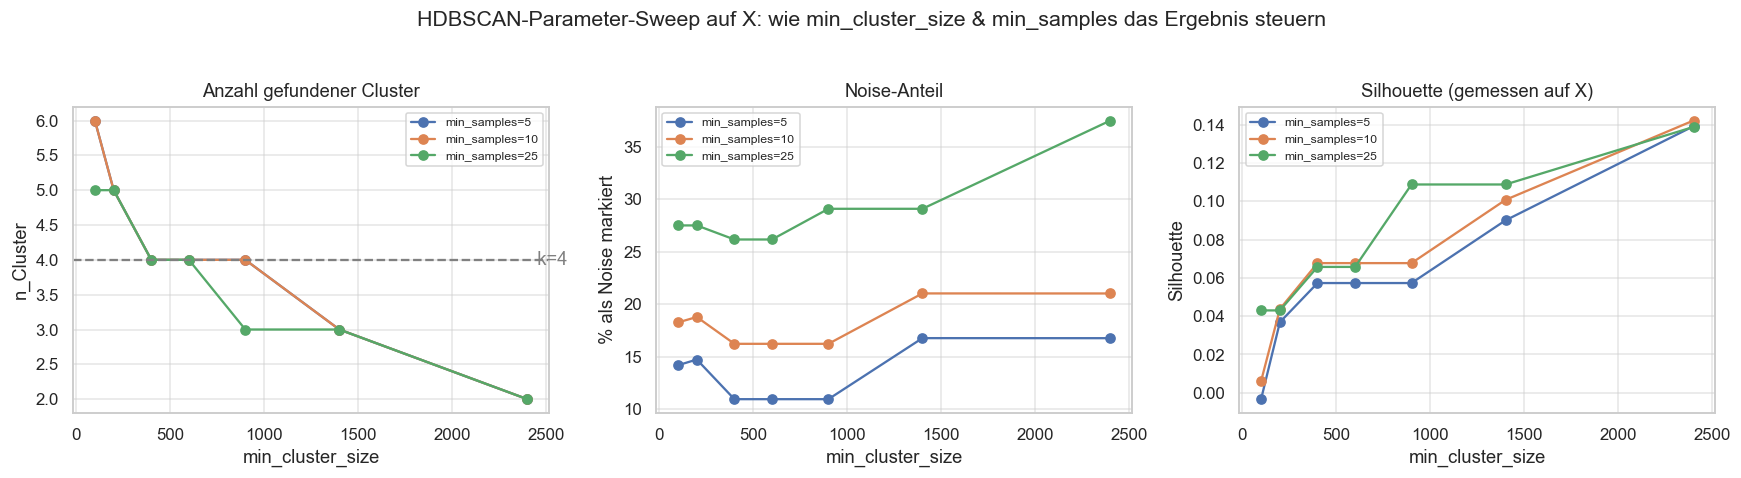

Lesart: min_cluster_size hoch  -> weniger Cluster (links Richtung k=4).
        min_samples     hoch  -> mehr Noise (mitte).
        Die Silhouette (rechts) bleibt auf diesen Daten durchweg niedrig
        -> HDBSCAN findet keine klare Dichtestruktur (Markt = Kontinuum).


In [26]:
#   min_cluster_size (x-Achse) -> je groesser, desto weniger/groebere Cluster
#   min_samples      (Kurven)  -> je groesser, desto mehr Noise
# Silhouette wird im echten Feature-Raum X gemessen (sil_on_X aus der Zelle oben).
ms_values = [5, 10, 25]                                  # min_samples-Kurven
mcs_grid  = [100, 200, 400, 600, 900, 1400, 2400]        # min_cluster_size (x-Achse)

fig, ax = plt.subplots(1, 3, figsize=(16, 4.2))
for ms in ms_values:
    ks, noises, sils = [], [], []
    for mcs in mcs_grid:
        lab = HDBSCAN(min_cluster_size=mcs, min_samples=ms).fit(X).labels_
        ks.append(len(set(lab.tolist()) - {-1}))
        noises.append((lab == -1).mean() * 100)
        sils.append(sil_on_X(lab))
    ax[0].plot(mcs_grid, ks,     "o-", label=f"min_samples={ms}")
    ax[1].plot(mcs_grid, noises, "o-", label=f"min_samples={ms}")
    ax[2].plot(mcs_grid, sils,   "o-", label=f"min_samples={ms}")

ax[0].axhline(K, ls="--", color="grey")
ax[0].text(mcs_grid[-1], K, "  k=4", va="center", color="grey")
ax[0].set(title="Anzahl gefundener Cluster", xlabel="min_cluster_size", ylabel="n_Cluster")
ax[1].set(title="Noise-Anteil", xlabel="min_cluster_size", ylabel="% als Noise markiert")
ax[2].set(title="Silhouette (gemessen auf X)", xlabel="min_cluster_size", ylabel="Silhouette")
for a in ax:
    a.legend(fontsize=8)
fig.suptitle("HDBSCAN-Parameter-Sweep auf X: wie min_cluster_size & min_samples das Ergebnis steuern",
             fontsize=14, y=1.03)
plt.tight_layout()
plt.show()

print("Lesart: min_cluster_size hoch  -> weniger Cluster (links Richtung k=4).")
print("        min_samples     hoch  -> mehr Noise (mitte).")
print("        Die Silhouette (rechts) bleibt auf diesen Daten durchweg niedrig")
print("        -> HDBSCAN findet keine klare Dichtestruktur (Markt = Kontinuum).")


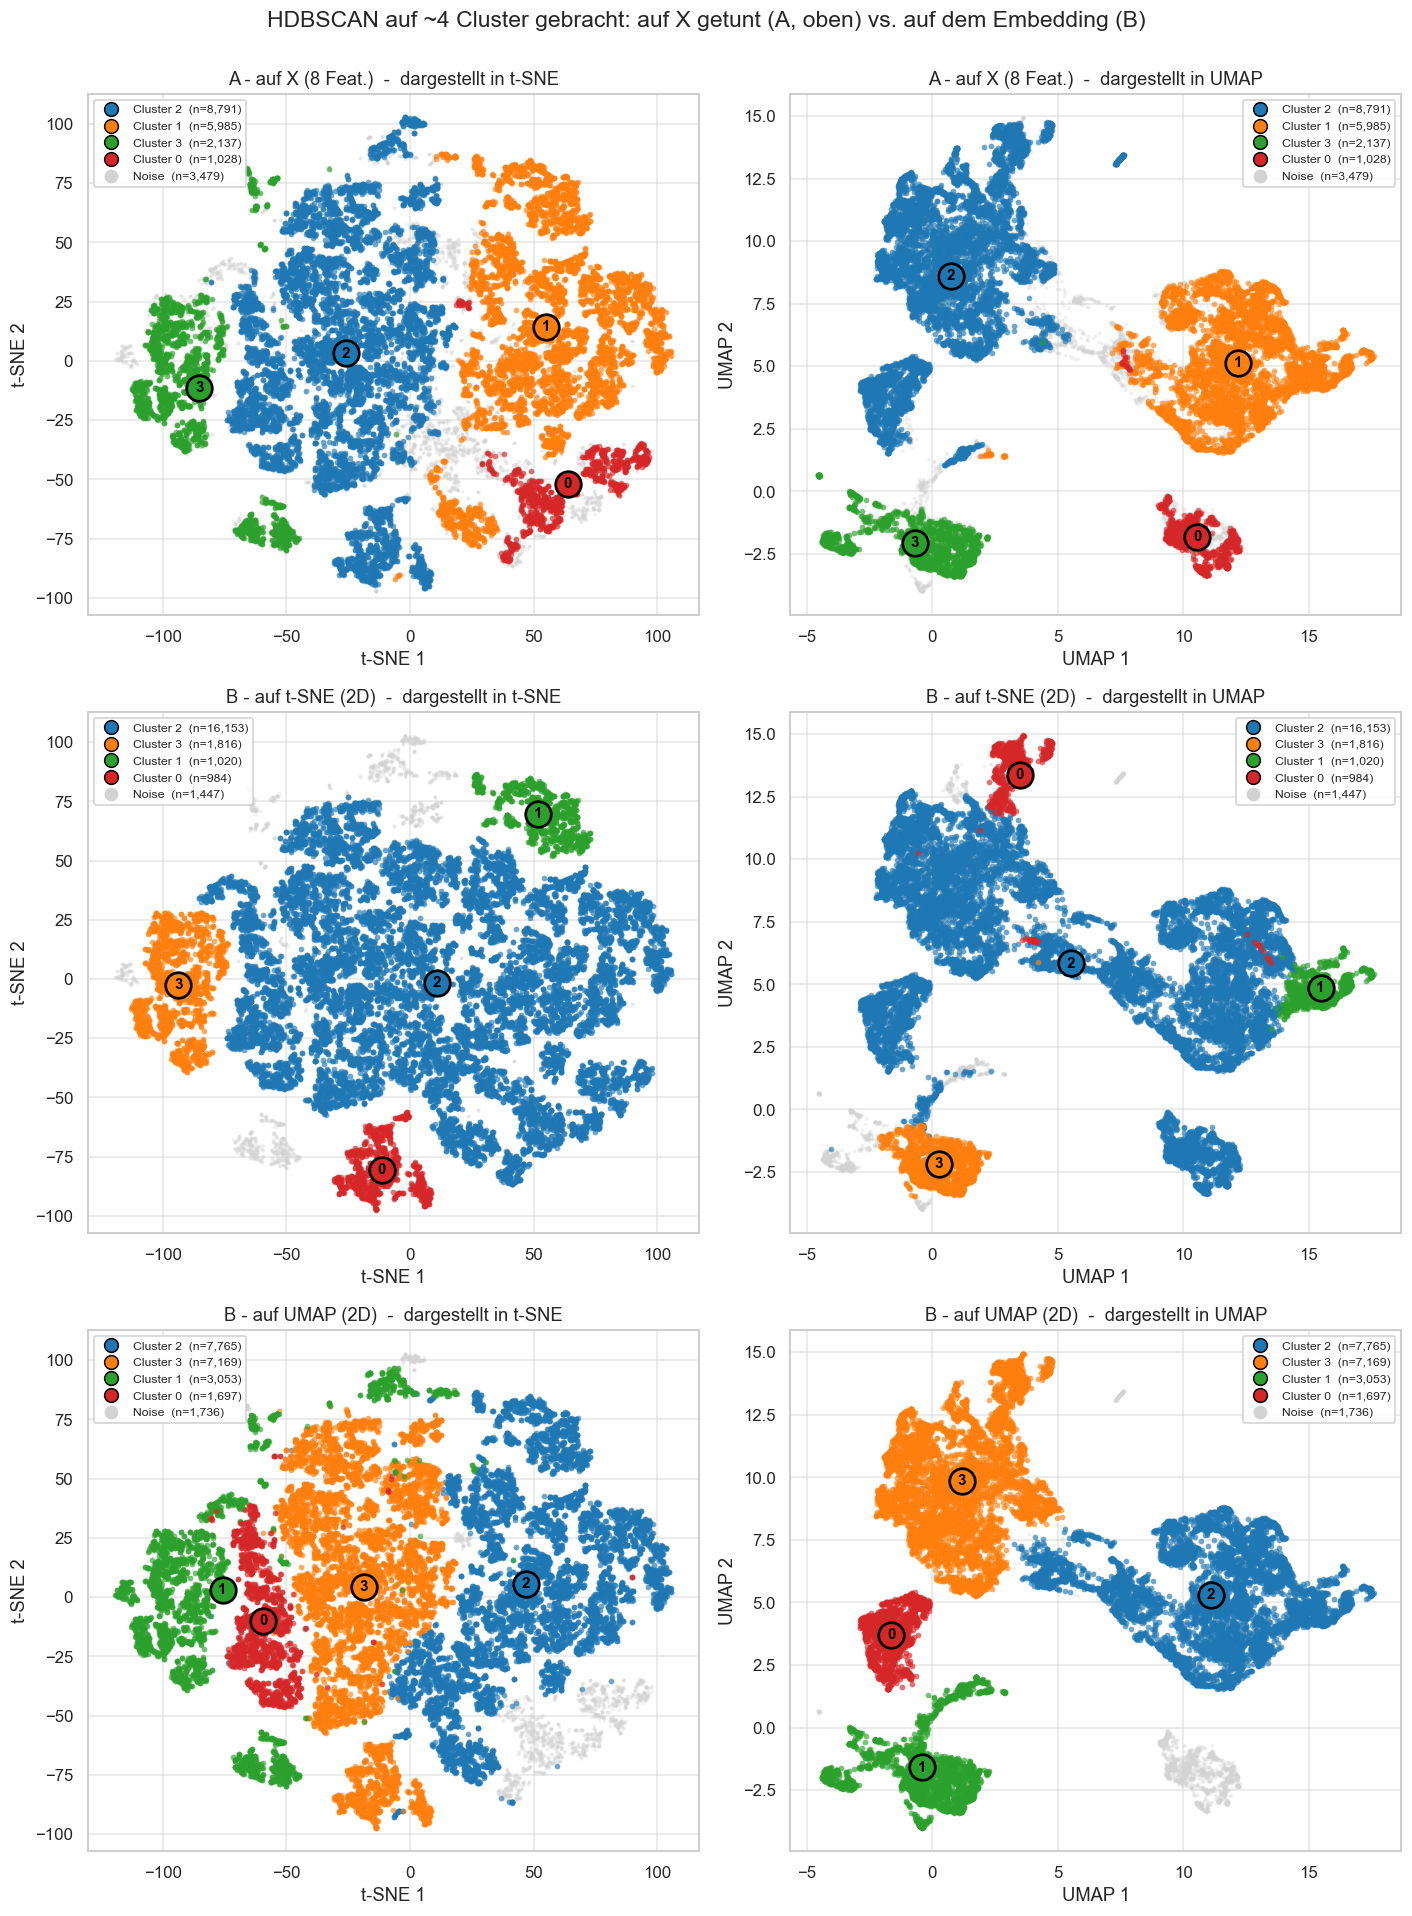

In [27]:
# Alle drei HDBSCAN-Varianten in BEIDEN Projektionen (t-SNE links, UMAP rechts).
# Gleiche Punkte (tsne_idx = alle 21.420) -> direkt vergleichbar mit den Grids oben.
variants = [
    ("A - auf X (8 Feat.)", labels_hdb_X),
    ("B - auf t-SNE (2D)",  labels_hdb_tsne),
    ("B - auf UMAP (2D)",   labels_hdb_umap),
]

fig, axes = plt.subplots(len(variants), 2, figsize=(13, 5.8 * len(variants)))
axes = np.atleast_2d(axes)
for r, (name, lab) in enumerate(variants):
    plot_clusters(lab, f"{name}  -  dargestellt in t-SNE", emb=X_tsne, idx=tsne_idx,
                  ax=axes[r, 0], xlabel="t-SNE 1", ylabel="t-SNE 2")
    plot_clusters(lab, f"{name}  -  dargestellt in UMAP", emb=X_umap, idx=tsne_idx,
                  ax=axes[r, 1], xlabel="UMAP 1", ylabel="UMAP 2")
fig.suptitle("HDBSCAN auf ~4 Cluster gebracht: auf X getunt (A, oben) vs. auf dem Embedding (B)",
             fontsize=15, y=1.0)
plt.tight_layout()
plt.show()


In [28]:
comparison = pd.DataFrame(results).set_index("Algorithmus")
comparison = comparison.sort_values("Silhouette", ascending=False)
comparison.round(3)

,n_Cluster,Noise,Silhouette,Davies_Bouldin
Algorithmus,,,,
DBSCAN,19,20883,0.406,0.914
DBSCAN,19,20883,0.406,0.914
K-Means,4,0,0.197,1.473
Hierarchical,4,0,0.142,1.774
GMM,4,0,0.072,2.384
HDBSCAN,5,4707,0.044,2.120


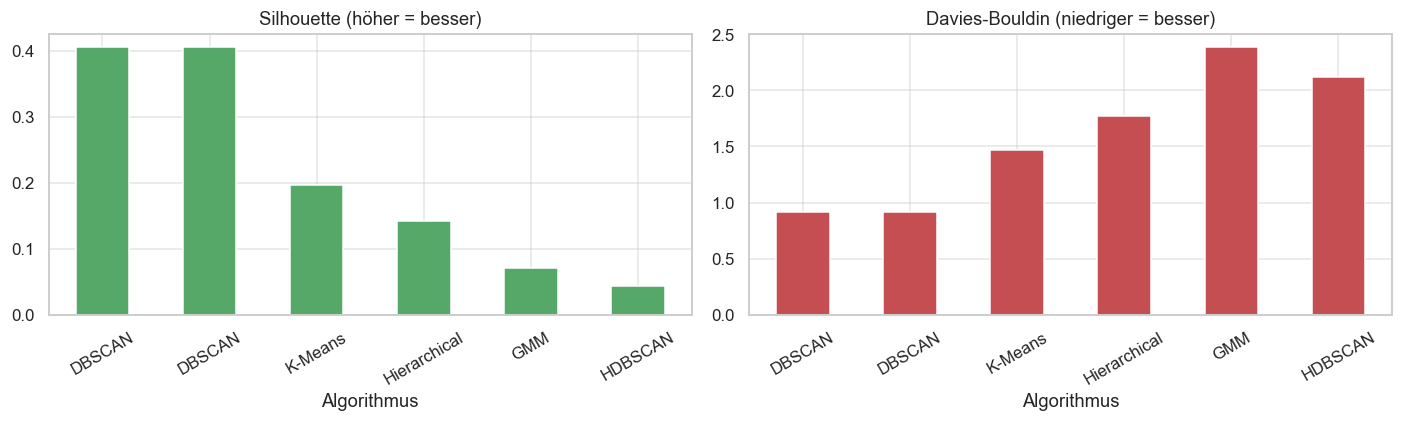

In [29]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
comparison["Silhouette"].plot.bar(ax=ax[0], color="#55A868")
ax[0].set_title("Silhouette (höher = besser)"); ax[0].tick_params(axis="x", rotation=30)
comparison["Davies_Bouldin"].plot.bar(ax=ax[1], color="#C44E52")
ax[1].set_title("Davies-Bouldin (niedriger = besser)"); ax[1].tick_params(axis="x", rotation=30)
plt.tight_layout(); plt.show()

Vollständige Segmentierungen (Noise <= 30 %), Rangfolge nach Silhouette:
              n_Cluster  Noise_%  Silhouette  Davies_Bouldin
Algorithmus                                                 
K-Means               4      0.0       0.197           1.473
Hierarchical          4      0.0       0.142           1.774
GMM                   4      0.0       0.072           2.384
HDBSCAN               5     22.0       0.044           2.120

Ausgeschlossen (zu viel Noise -> keine echte Segmentierung): ['DBSCAN']
>> Die zwei besten Clusterings: ['K-Means', 'Hierarchical']


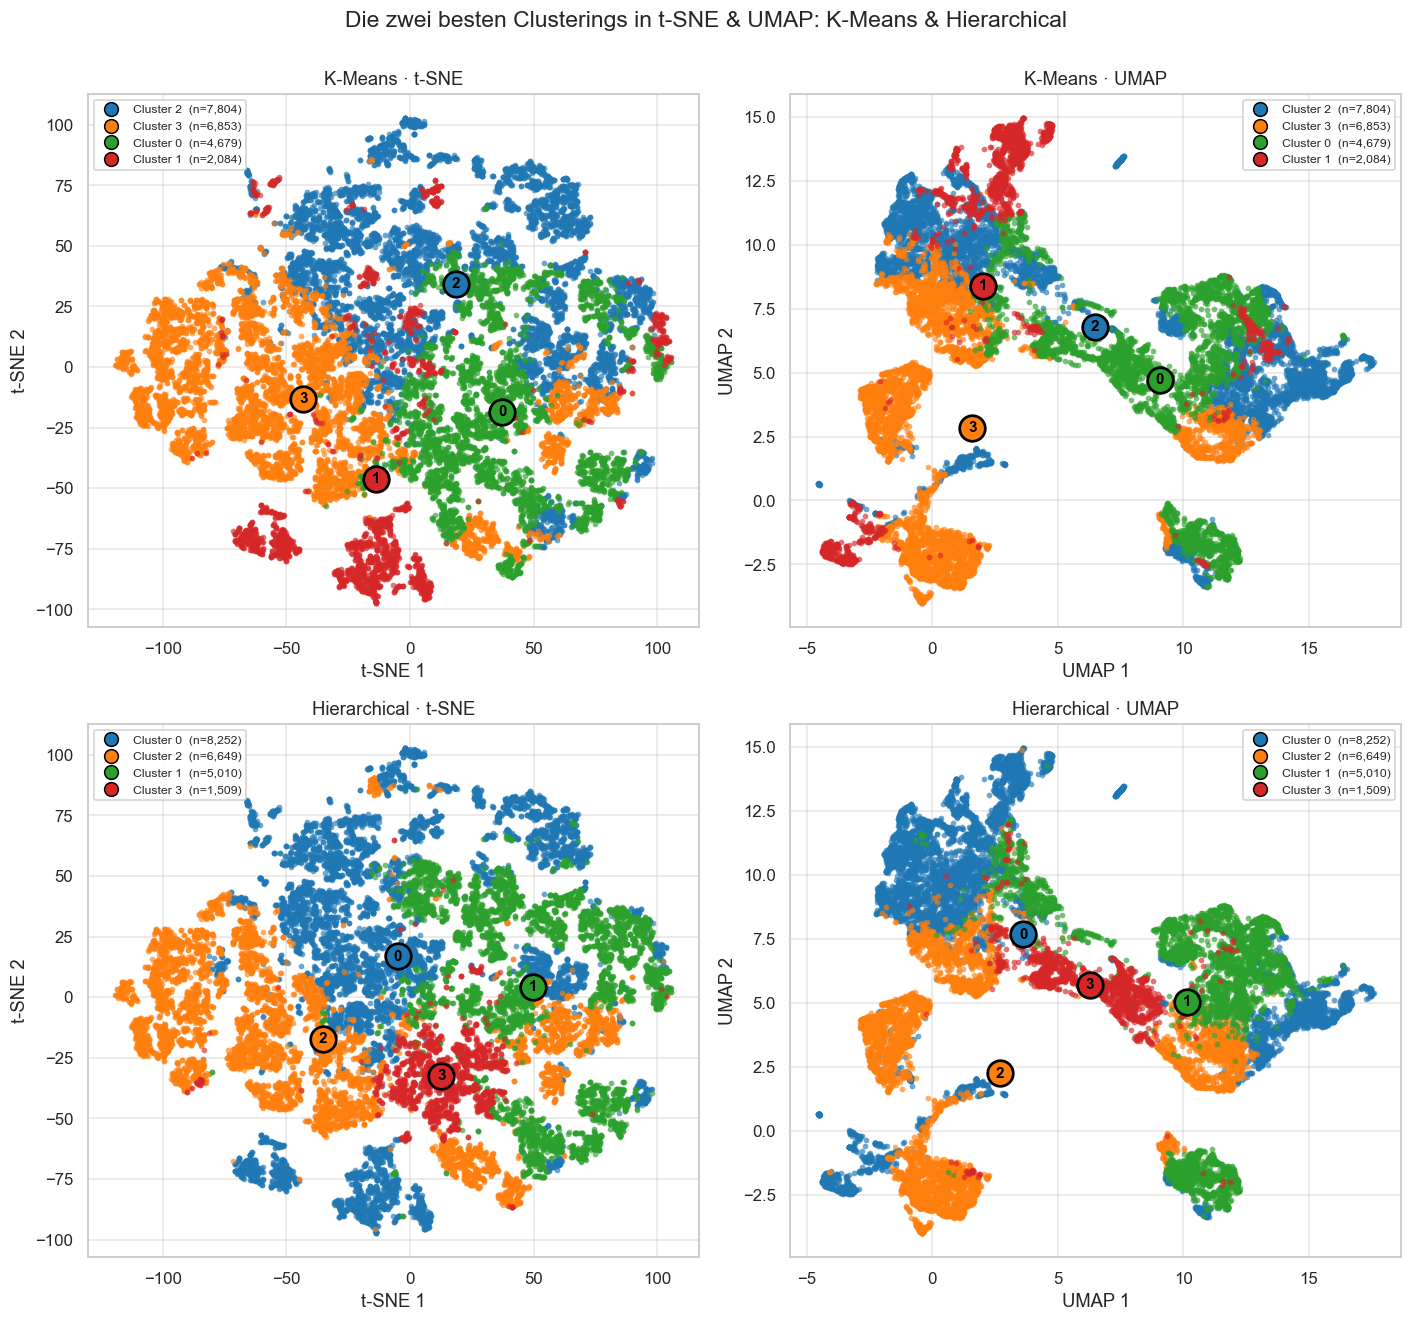

In [30]:
# --- Auswahl der ZWEI BESTEN Clusterings ---
comp = pd.DataFrame(results).set_index("Algorithmus")
comp["Noise_%"] = (comp["Noise"] / len(X) * 100).round(1)

MAX_NOISE_FRAC = 0.30
valid = comp[comp["Noise"] / len(X) <= MAX_NOISE_FRAC]
ranked = valid.sort_values(["Silhouette", "Davies_Bouldin"], ascending=[False, True])
best_names = list(ranked.head(2).index)

print("Vollständige Segmentierungen (Noise <= 30 %), Rangfolge nach Silhouette:")
print(ranked[["n_Cluster", "Noise_%", "Silhouette", "Davies_Bouldin"]].round(3))
print("\nAusgeschlossen (zu viel Noise -> keine echte Segmentierung):",
      list(comp.index.difference(valid.index)))
print(">> Die zwei besten Clusterings:", best_names)

# --- Genau diese zwei in t-SNE UND UMAP visualisieren (Deliverable 3) ---
label_map = {"K-Means": labels_km, "Hierarchical": labels_agg, "DBSCAN": labels_db,
             "HDBSCAN": labels_hdb, "GMM": labels_gmm}

fig, axes = plt.subplots(len(best_names), 2, figsize=(13, 6 * len(best_names)))
axes = np.atleast_2d(axes)
for r, name in enumerate(best_names):
    plot_clusters(label_map[name], f"{name} · t-SNE", emb=X_tsne, idx=tsne_idx,
                  ax=axes[r, 0], xlabel="t-SNE 1", ylabel="t-SNE 2")
    plot_clusters(label_map[name], f"{name} · UMAP", emb=X_umap, idx=tsne_idx,
                  ax=axes[r, 1], xlabel="UMAP 1", ylabel="UMAP 2")
fig.suptitle(f"Die zwei besten Clusterings in t-SNE & UMAP: {best_names[0]} & {best_names[1]}",
             fontsize=15, y=1.0)
plt.tight_layout(); plt.show()

## 7 · Cluster-Profile & Abgleich mit den Hypothesen
Wir nehmen die Zuordnung des am besten interpretierbaren Verfahrens (K-Means, k=4) und schauen uns die **mittleren (standardisierten) Feature-Werte je Cluster** an. Positiv = über Durchschnitt, negativ = darunter. Daraus lesen wir ab, welches Cluster zu H1/H2/H3/H4 passt.

In [31]:
prof = df.copy()
prof["cluster"] = labels_km
profile = prof.groupby("cluster").mean()
sizes = prof["cluster"].value_counts().sort_index()
profile.insert(0, "n", sizes)
profile.round(2)

,n,log_price,log_sqft_living,log_yard_space_approx,bedrooms,bathrooms,luxury_score,distance_to_center,years_since_renovation
cluster,,,,,,,,,
0,4679,1.23,1.15,0.30,0.87,0.99,1.02,-0.25,-0.20
1,2084,-0.11,-0.52,-1.62,-0.62,0.24,-0.41,-0.81,-1.02
2,7804,-0.29,0.21,0.34,0.15,0.21,-0.26,0.81,-0.48
3,6853,-0.48,-0.86,-0.10,-0.58,-0.99,-0.27,-0.50,0.99


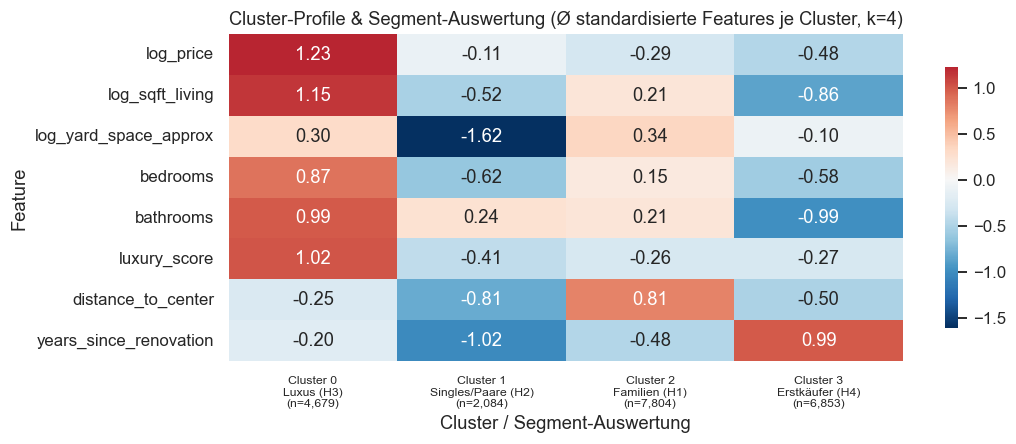

In [32]:
# Interpretation je Cluster (aus den Profil-Mittelwerten oben abgeleitet, k=4).
# Deterministisch bei RANDOM_STATE=42; falls sich die Cluster-Nummern bei einem
# erneuten Lauf verschieben, hier einmal anpassen.
segment_names = {
    0: "Luxus (H3)",
    1: "Singles/Paare (H2)",
    2: "Familien (H1)",
    3: "Erstkäufer (H4)",
}

hm = profile.drop(columns="n").T          # Features = Zeilen (y), Cluster = Spalten (x)
xlabels = [f"Cluster {c}\n{segment_names.get(c, '?')}\n(n={int(profile.loc[c, 'n']):,})"
           for c in hm.columns]

plt.figure(figsize=(10, 4.2))
ax = sns.heatmap(hm, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
                 cbar_kws={"shrink": .8})
ax.set_xticklabels(xlabels, rotation=0, fontsize=8)
plt.title("Cluster-Profile & Segment-Auswertung (Ø standardisierte Features je Cluster, k=4)")
plt.xlabel("Cluster / Segment-Auswertung"); plt.ylabel("Feature")
plt.tight_layout(); plt.show()

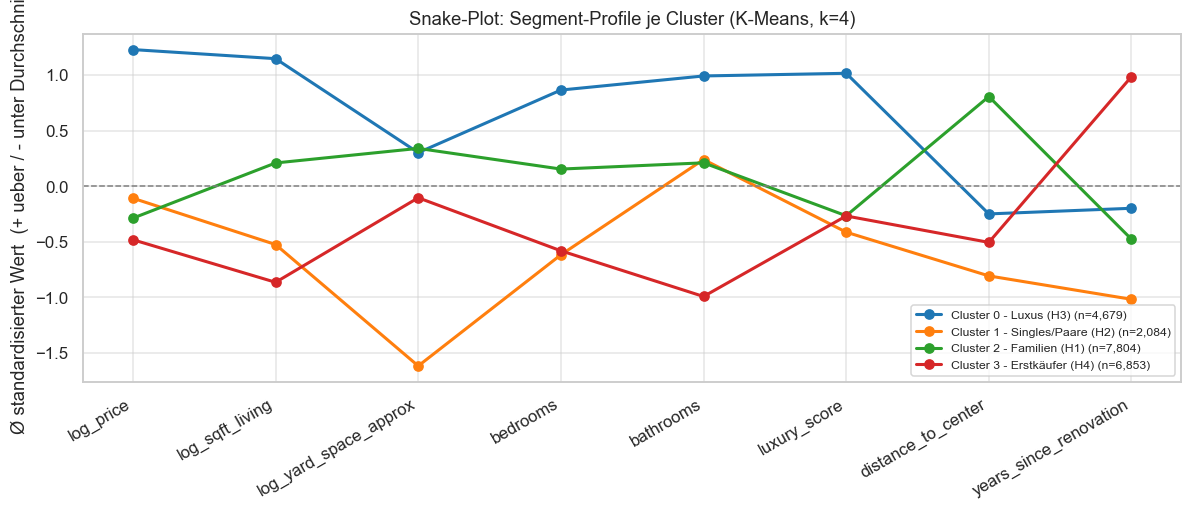

In [33]:
# Snake-Plot: Profil-Linie je Cluster über alle Features (Klassiker der Segmentierung).
# Zeigt die Trennschärfe der Segmente viel klarer als der überlappende t-SNE/UMAP-Scatter,
# weil hier die CLUSTER-MITTELWERTE verglichen werden, nicht die Einzelpunkte.
prof_only = profile.drop(columns="n")
cmap = plt.get_cmap("tab10")

plt.figure(figsize=(11, 4.8))
for c in prof_only.index:
    plt.plot(prof_only.columns, prof_only.loc[c], "o-", linewidth=2, color=cmap(c % 10),
             label=f"Cluster {c} - {segment_names.get(c, '?')} (n={int(profile.loc[c, 'n']):,})")
plt.axhline(0, color="grey", lw=1, ls="--")           # 0 = Gesamtdurchschnitt
plt.xticks(rotation=30, ha="right")
plt.ylabel("Ø standardisierter Wert  (+ ueber / - unter Durchschnitt)")
plt.title("Snake-Plot: Segment-Profile je Cluster (K-Means, k=4)")
plt.legend(fontsize=8, loc="best")
plt.tight_layout(); plt.show()


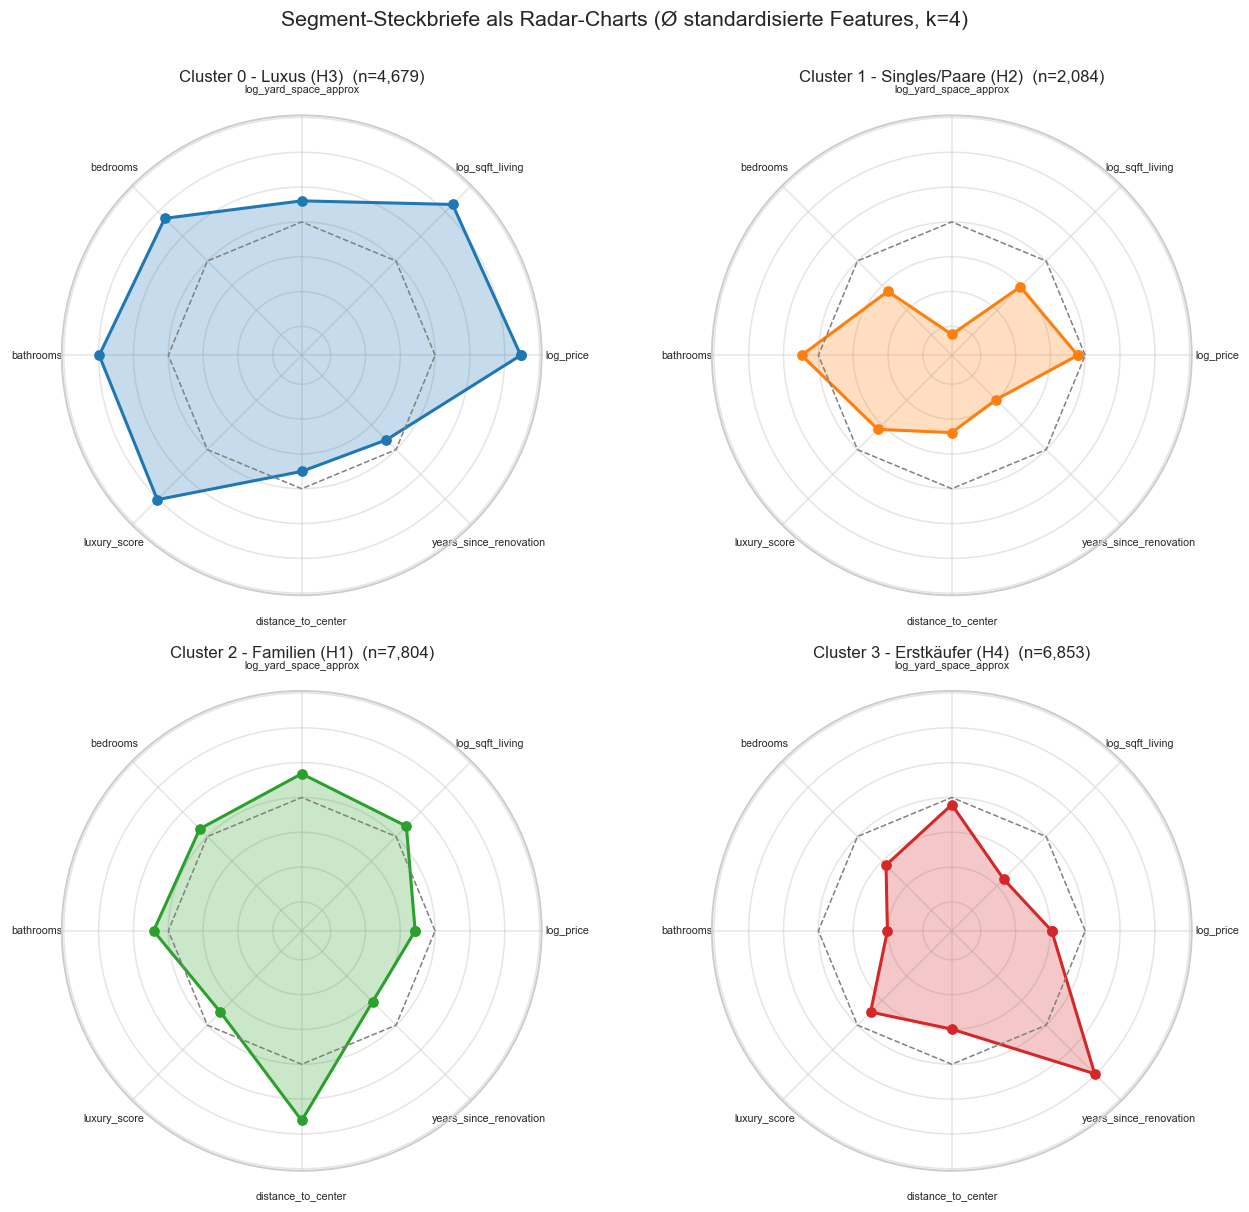

In [34]:
# Radar-Charts: ein Netz je Segment (Persona-Darstellung).
# Gleiche radiale Skala fuer alle vier -> die Formen sind direkt vergleichbar.
feats = list(profile.drop(columns="n").columns)
N = len(feats)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]                      # Kreis schliessen

vals_all = profile.drop(columns="n").values
gmin, gmax = float(vals_all.min()) - 0.3, float(vals_all.max()) + 0.3
cmap = plt.get_cmap("tab10")

fig, axes = plt.subplots(2, 2, figsize=(12, 11), subplot_kw=dict(polar=True))
for ax, c in zip(axes.ravel(), profile.index):
    vals = profile.drop(columns="n").loc[c].tolist()
    vals += vals[:1]
    ax.plot(angles, vals, "o-", linewidth=2, color=cmap(c % 10))
    ax.fill(angles, vals, color=cmap(c % 10), alpha=0.25)
    ax.plot(angles, [0] * len(angles), color="grey", lw=1, ls="--")   # 0 = Durchschnitt
    ax.set_ylim(gmin, gmax)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(feats, fontsize=7)
    ax.set_yticklabels([])
    ax.set_title(f"Cluster {c} - {segment_names.get(c, '?')}  (n={int(profile.loc[c, 'n']):,})",
                 fontsize=11, pad=22)
fig.suptitle("Segment-Steckbriefe als Radar-Charts (Ø standardisierte Features, k=4)",
             fontsize=14, y=1.0)
plt.tight_layout(); plt.show()
